## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

In [76]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

In [77]:
%%duckdb -o gender_1_duration


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
) where gender =1 
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
1,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6
2,384,Fulton St & Waverly Ave,40.683178,-73.965964,399,Lafayette Ave & St James Pl,40.688515,-73.964763,19610,Subscriber,1969.0,1,2015-01-01 00:04:00,2015-01-01 00:07:00,3


# Veriyi Tanıma ve İlk Hazırlık

Burada önce ham veriyi okuyup temel feature view'larını çıkarıyorum. Model kısmına geçmeden önce veriyle biraz uğraşmak şart; yoksa model güzel skor verse bile ne öğrendiğini anlamak zor oluyor.


In [78]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

con = duckdb.connect()

# S3 parquet okumak için
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")

DATA_PATH = "s3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet"

con.sql(f"""
CREATE OR REPLACE VIEW trips_features AS
WITH parsed AS (
    SELECT
        "start station id" AS start_station_id,
        "start station name" AS start_station_name,
        CAST("start station latitude" AS DOUBLE) AS start_lat,
        CAST("start station longitude" AS DOUBLE) AS start_lon,

        "end station id" AS end_station_id,
        "end station name" AS end_station_name,
        CAST("end station latitude" AS DOUBLE) AS end_lat,
        CAST("end station longitude" AS DOUBLE) AS end_lon,

        bikeid,
        usertype,
        CAST("birth year" AS DOUBLE) AS birth_year,
        CAST(gender AS INTEGER) AS gender,

        strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
        strptime(stoptime,  ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
    FROM '{DATA_PATH}'
),
with_time AS (
    SELECT
        *,
        date_diff('second', start_at, stop_at) / 60.0 AS duration_min,
        date_part('year', start_at) AS start_year,
        date_part('month', start_at) AS start_month,
        date_part('hour', start_at) AS start_hour,
        date_part('dayofweek', start_at) AS day_of_week,
        CASE 
            WHEN date_part('dayofweek', start_at) IN (0, 6) THEN 1 
            ELSE 0 
        END AS is_weekend,
        CASE 
            WHEN start_station_id = end_station_id THEN 1 
            ELSE 0 
        END AS is_roundtrip,
        date_part('year', start_at) - birth_year AS age_at_trip
    FROM parsed
),
with_distance AS (
    SELECT
        *,
        6371.0088 * 2 * asin(
            sqrt(
                power(sin(((end_lat - start_lat) * pi() / 180) / 2), 2)
                +
                cos(start_lat * pi() / 180)
                * cos(end_lat * pi() / 180)
                * power(sin(((end_lon - start_lon) * pi() / 180) / 2), 2)
            )
        ) AS distance_km
    FROM with_time
)
SELECT
    *,
    distance_km * 0.621371 AS distance_miles,
    CASE 
        WHEN duration_min > 0 THEN distance_km / (duration_min / 60.0)
        ELSE NULL
    END AS speed_kmh
FROM with_distance;
""")

print("trips_features view hazır.")

trips_features view hazır.


In [4]:
dist_summary = con.sql("""
SELECT
    COUNT(*) AS n,

    MIN(duration_min) AS dur_min,
    quantile_cont(duration_min, 0.01) AS dur_p01,
    quantile_cont(duration_min, 0.05) AS dur_p05,
    quantile_cont(duration_min, 0.50) AS dur_median,
    quantile_cont(duration_min, 0.95) AS dur_p95,
    quantile_cont(duration_min, 0.99) AS dur_p99,
    MAX(duration_min) AS dur_max,

    MIN(distance_km) AS dist_min,
    quantile_cont(distance_km, 0.01) AS dist_p01,
    quantile_cont(distance_km, 0.50) AS dist_median,
    quantile_cont(distance_km, 0.95) AS dist_p95,
    quantile_cont(distance_km, 0.99) AS dist_p99,
    MAX(distance_km) AS dist_max,

    MIN(speed_kmh) AS speed_min,
    quantile_cont(speed_kmh, 0.01) AS speed_p01,
    quantile_cont(speed_kmh, 0.50) AS speed_median,
    quantile_cont(speed_kmh, 0.95) AS speed_p95,
    quantile_cont(speed_kmh, 0.99) AS speed_p99,
    MAX(speed_kmh) AS speed_max
FROM trips_features
WHERE duration_min IS NOT NULL
  AND distance_km IS NOT NULL
  AND speed_kmh IS NOT NULL;
""").df()

display(dist_summary)

,n,dur_min,dur_p01,dur_p05,dur_median,dur_p95,dur_p99,dur_max,dist_min,dist_p01,dist_median,dist_p95,dist_p99,dist_max,speed_min,speed_p01,speed_median,speed_p95,speed_p99,speed_max
0,23783471,1.0,1.983333,3.183333,10.516667,33.766667,64.616667,148832.55,0.0,0.0,1.408308,4.452852,6.388586,8668.008801,0.0,0.0,8.913203,13.727435,16.012658,380503.067004


In [79]:
monthly = con.sql("""
SELECT
    start_year,
    start_month,
    COUNT(*) AS n,
    AVG(duration_min) AS avg_duration,
    quantile_cont(duration_min, 0.5) AS median_duration,
    AVG(distance_km) AS avg_distance,
    AVG(speed_kmh) AS avg_speed
FROM trips_features
WHERE duration_min BETWEEN 1 AND 240
  AND distance_km BETWEEN 0 AND 40
  AND speed_kmh BETWEEN 0 AND 45
GROUP BY start_year, start_month
ORDER BY start_year, start_month;
""").df()

display(monthly)

hourly = con.sql("""
SELECT
    start_hour,
    COUNT(*) AS n,
    quantile_cont(duration_min, 0.5) AS median_duration,
    AVG(duration_min) AS avg_duration,
    AVG(distance_km) AS avg_distance,
    AVG(speed_kmh) AS avg_speed
FROM trips_features
WHERE duration_min BETWEEN 1 AND 240
  AND distance_km BETWEEN 0 AND 40
  AND speed_kmh BETWEEN 0 AND 45
GROUP BY start_hour
ORDER BY start_hour;
""").df()

display(hourly)

user_gender = con.sql("""
SELECT
    usertype,
    gender,
    COUNT(*) AS n,
    quantile_cont(duration_min, 0.5) AS median_duration,
    quantile_cont(distance_km, 0.5) AS median_distance,
    quantile_cont(speed_kmh, 0.5) AS median_speed
FROM trips_features
WHERE duration_min BETWEEN 1 AND 240
  AND distance_km BETWEEN 0 AND 40
  AND speed_kmh BETWEEN 0 AND 45
GROUP BY usertype, gender
ORDER BY usertype, gender;
""").df()

display(user_gender)

,start_year,start_month,n,avg_duration,median_duration,avg_distance,avg_speed
0,2015,1,285363,10.624194,8.000000,1.459465,8.979807
1,2015,2,196776,10.526370,8.000000,1.424698,8.735225
2,2015,3,341558,11.433452,9.000000,1.561409,8.939151
3,2015,4,651422,13.560151,10.200000,1.701339,8.643062
4,2015,5,960183,14.989402,11.233333,1.752229,8.296078
5,2015,6,939966,14.129300,11.000000,1.725007,8.485193
6,2015,7,1083612,14.700227,11.100000,1.734879,8.305333
7,2015,8,1176753,15.138904,11.333333,1.752792,8.249989
8,2015,9,1285638,14.951630,11.133333,1.779354,8.403368
9,2015,10,1208074,14.073446,10.533333,1.763901,8.727922


,start_hour,n,median_duration,avg_duration,avg_distance,avg_speed
0,0,218849,9.700000,12.605721,1.687510,9.066510
1,1,120260,9.433333,12.605877,1.665286,9.097097
2,2,70440,9.433333,12.704191,1.670290,9.157700
3,3,44128,9.300000,12.609213,1.614505,9.145284
4,4,41999,8.616667,11.866584,1.679895,9.877288
5,5,132976,8.000000,10.525042,1.739070,10.751354
6,6,512346,8.283333,10.633274,1.778676,10.632958
7,7,1084327,9.366667,11.836095,1.911957,10.159950
8,8,1924601,10.116667,12.632575,1.938111,9.655629
9,9,1523347,9.850000,12.821633,1.771737,9.195010


,usertype,gender,n,median_duration,median_distance,median_speed
0,Customer,0,2764100,20.933333,1.616372,5.511545
1,Customer,1,20614,20.266667,1.764768,6.041833
2,Customer,2,13463,22.050000,1.800618,5.524914
3,Subscriber,0,157462,12.283333,1.421912,8.086520
4,Subscriber,1,15788096,9.266667,1.364950,9.476438
5,Subscriber,2,4959655,11.000000,1.438283,8.498478
6,None,0,356,18.266667,1.693902,6.060508
7,None,1,23037,19.400000,1.722136,6.148001
8,None,2,12376,21.800000,1.793731,5.555165


In [80]:
con.sql("""
CREATE OR REPLACE VIEW trips_duration_clean AS
SELECT *
FROM trips_features
WHERE duration_min BETWEEN 1 AND 240
  AND distance_km BETWEEN 0 AND 40
  AND start_lat BETWEEN 40.45 AND 41.10
  AND end_lat BETWEEN 40.45 AND 41.10
  AND start_lon BETWEEN -74.30 AND -73.60
  AND end_lon BETWEEN -74.30 AND -73.60
  AND birth_year IS NOT NULL
  AND age_at_trip BETWEEN 14 AND 90
  AND usertype IS NOT NULL;
""")

con.sql("""
CREATE OR REPLACE VIEW trips_speed_gender_clean AS
SELECT *
FROM trips_features
WHERE gender IN (1, 2)
  AND duration_min BETWEEN 1 AND 180
  AND distance_km BETWEEN 0.10 AND 35
  AND speed_kmh BETWEEN 1 AND 45
  AND birth_year IS NOT NULL
  AND age_at_trip BETWEEN 14 AND 90;
""")

clean_check = con.sql("""
SELECT 'raw' AS dataset, COUNT(*) AS n FROM trips_features
UNION ALL
SELECT 'duration_clean' AS dataset, COUNT(*) AS n FROM trips_duration_clean
UNION ALL
SELECT 'speed_gender_clean' AS dataset, COUNT(*) AS n FROM trips_speed_gender_clean;
""").df()

display(clean_check)

,dataset,n
0,raw,23783624
1,duration_clean,20818147
2,speed_gender_clean,20406670


In [81]:
sample_duration = con.sql("""
SELECT
    duration_min,
    distance_km,
    distance_miles,
    speed_kmh,
    start_hour,
    day_of_week,
    is_weekend,
    is_roundtrip,
    usertype,
    gender,
    age_at_trip
FROM trips_duration_clean
WHERE random() < 0.01
LIMIT 60000;
""").df()

sample_gender = con.sql("""
SELECT
    gender,
    speed_kmh,
    log(speed_kmh) AS log_speed,
    duration_min,
    distance_km,
    start_hour,
    is_weekend,
    age_at_trip
FROM trips_speed_gender_clean
WHERE random() < 0.02
LIMIT 60000;
""").df()

print(sample_duration.shape)
print(sample_gender.shape)

display(sample_duration.head())
display(sample_gender.head())

(60000, 11)
(60000, 8)


,duration_min,distance_km,distance_miles,speed_kmh,start_hour,day_of_week,is_weekend,is_roundtrip,usertype,gender,age_at_trip
0,3.0,0.431101,0.267874,8.622020,0,4,0,0,Subscriber,1,47.0
1,10.0,0.993399,0.617269,5.960395,1,4,0,0,Subscriber,1,39.0
2,9.0,1.285153,0.798557,8.567684,1,4,0,0,Subscriber,1,51.0
3,18.0,1.986954,1.234636,6.623180,2,4,0,0,Subscriber,2,31.0
4,13.0,1.986905,1.234605,9.170333,2,4,0,0,Subscriber,1,47.0


,gender,speed_kmh,log_speed,duration_min,distance_km,start_hour,is_weekend,age_at_trip
0,2,12.428382,1.094415,8.0,1.657118,0,0,46.0
1,1,5.824414,0.765252,12.0,1.164883,0,0,27.0
2,1,12.029667,1.080254,12.0,2.405933,1,0,35.0
3,1,11.354169,1.055155,3.0,0.567708,1,0,31.0
4,1,7.178521,0.856035,11.0,1.316062,1,0,43.0


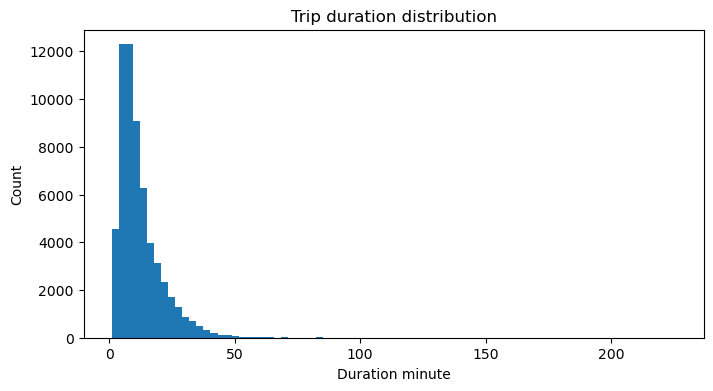

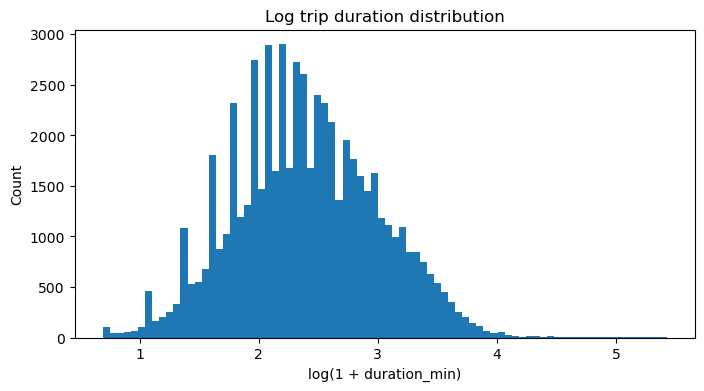

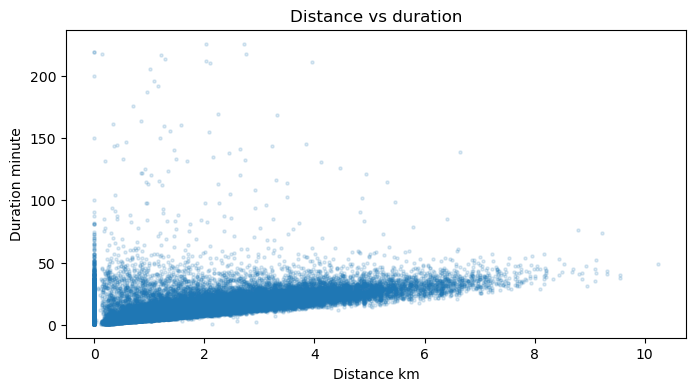

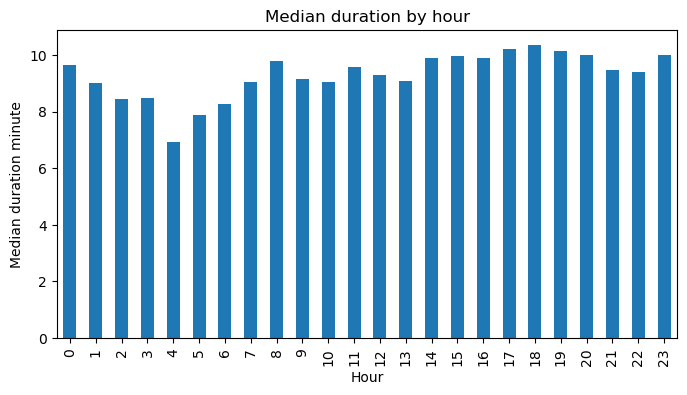

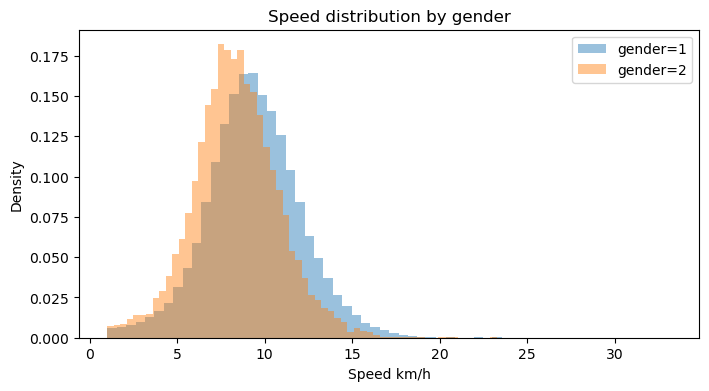

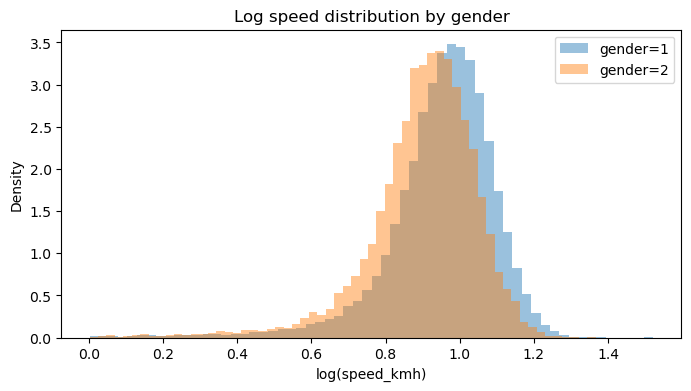

In [82]:
plt.figure(figsize=(8, 4))
plt.hist(sample_duration["duration_min"], bins=80)
plt.title("Trip duration distribution")
plt.xlabel("Duration minute")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(sample_duration["duration_min"]), bins=80)
plt.title("Log trip duration distribution")
plt.xlabel("log(1 + duration_min)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(sample_duration["distance_km"], sample_duration["duration_min"], alpha=0.15, s=5)
plt.title("Distance vs duration")
plt.xlabel("Distance km")
plt.ylabel("Duration minute")
plt.show()

hour_median = sample_duration.groupby("start_hour")["duration_min"].median()

plt.figure(figsize=(8, 4))
hour_median.plot(kind="bar")
plt.title("Median duration by hour")
plt.xlabel("Hour")
plt.ylabel("Median duration minute")
plt.show()

plt.figure(figsize=(8, 4))
for g in sorted(sample_gender["gender"].dropna().unique()):
    values = sample_gender.loc[sample_gender["gender"] == g, "speed_kmh"]
    plt.hist(values, bins=60, alpha=0.45, density=True, label=f"gender={g}")

plt.title("Speed distribution by gender")
plt.xlabel("Speed km/h")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
for g in sorted(sample_gender["gender"].dropna().unique()):
    values = sample_gender.loc[sample_gender["gender"] == g, "log_speed"]
    plt.hist(values, bins=60, alpha=0.45, density=True, label=f"gender={g}")

plt.title("Log speed distribution by gender")
plt.xlabel("log(speed_kmh)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [83]:
corr_cols = [
    "duration_min",
    "distance_km",
    "distance_miles",
    "speed_kmh",
    "start_hour",
    "day_of_week",
    "is_weekend",
    "is_roundtrip",
    "age_at_trip",
    "gender"
]

corr = sample_duration[corr_cols].corr(numeric_only=True)
display(corr)

,duration_min,distance_km,distance_miles,speed_kmh,start_hour,day_of_week,is_weekend,is_roundtrip,age_at_trip,gender
duration_min,1.000000,0.613272,0.613272,-0.268255,0.044099,0.002475,0.043181,0.086246,0.032817,0.088230
distance_km,0.613272,1.000000,1.000000,0.325589,0.005034,-0.000966,-0.013771,-0.175893,-0.020683,0.030273
distance_miles,0.613272,1.000000,1.000000,0.325589,0.005034,-0.000966,-0.013771,-0.175893,-0.020683,0.030273
speed_kmh,-0.268255,0.325589,0.325589,1.000000,-0.085104,-0.013893,-0.072181,-0.373721,-0.103804,-0.143612
start_hour,0.044099,0.005034,0.005034,-0.085104,1.000000,-0.031952,0.025723,0.011329,-0.057845,0.004264
day_of_week,0.002475,-0.000966,-0.000966,-0.013893,-0.031952,1.000000,-0.010700,0.003292,0.008958,-0.004066
is_weekend,0.043181,-0.013771,-0.013771,-0.072181,0.025723,-0.010700,1.000000,0.019570,-0.051963,0.049574
is_roundtrip,0.086246,-0.175893,-0.175893,-0.373721,0.011329,0.003292,0.019570,1.000000,0.015557,0.012316
age_at_trip,0.032817,-0.020683,-0.020683,-0.103804,-0.057845,0.008958,-0.051963,0.015557,1.000000,-0.059985
gender,0.088230,0.030273,0.030273,-0.143612,0.004264,-0.004066,0.049574,0.012316,-0.059985,1.000000


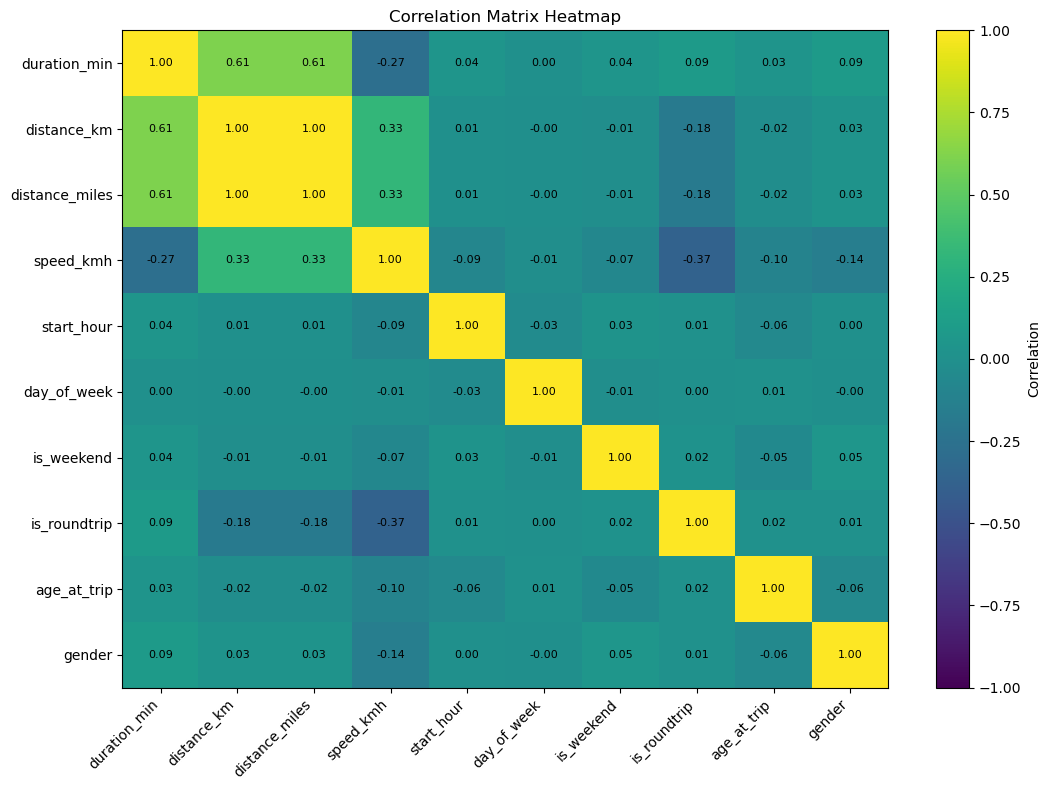

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# Korelasyon matrisi
corr_cols = [
    "duration_min",
    "distance_km",
    "distance_miles",
    "speed_kmh",
    "start_hour",
    "day_of_week",
    "is_weekend",
    "is_roundtrip",
    "age_at_trip",
    "gender"
]

corr = sample_duration[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
im = plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)

plt.colorbar(im, label="Correlation")

plt.xticks(
    ticks=np.arange(len(corr.columns)),
    labels=corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(corr.index)),
    labels=corr.index
)

# Hücrelerin içine korelasyon değerlerini yaz
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

## Veri Keşfi ve İlk Bulgular

Bu bölümde önce modeli kurmaya dalmadan veriyi gerçekten tanımaya çalıştım. Çünkü bu veri setinde direkt modele basınca sonuç alınır gibi duruyor ama içeride ciddi aykırı değer, sıfır mesafe, gerçek dışı hız ve uzun kuyruk problemi var.

Veri setinde toplam **23,783,624** yolculuk bulunmaktadır. Veri aralığı **2015-01-01** ile **2016-12-31** arasını kapsamaktadır. Veri içinde yaklaşık **10,990 farklı bisiklet**, **662 başlangıç istasyonu**, **689 bitiş istasyonu** ve **259,441 farklı istasyon çifti** bulunmaktadır. Yani veri hem büyük hem de rota çeşitliliği açısından oldukça zengin.

İlk kontrolde ham veride çok ciddi aykırı değerler olduğu görüldü. Maksimum yolculuk süresi yaklaşık **148,832 dakika**, maksimum mesafe yaklaşık **8,668 km**, maksimum hız ise fiziksel olarak mümkün olmayan şekilde **380,503 km/saat** olarak hesaplandı. Bu tarz değerler modelin öğrenmesini bozabileceği için temizlik aşaması şart.

Ayrıca yaklaşık **487,138 adet sıfır mesafeli yolculuk** var. Bunların bir kısmı gerçekten aynı istasyonda başlayıp biten kısa kullanımlar olabilir; fakat hız ve mesafe hesabında bu kayıtlar dikkatli ele alınmazsa modeli yanıltır.

### Yolculuk Süresi Dağılımı

Yolculuk süresi dağılımı sağa çarpık bir yapı gösteriyor. Yolculukların büyük çoğunluğu kısa sürüyor, az sayıda çok uzun yolculuk ise dağılımın kuyruğunu uzatıyor.

Bu yüzden süre değişkenini incelerken sadece ortalamaya bakmak yeterli değil. Medyan, yüzdelikler ve aykırı değerler birlikte kontrol edilmeli.

### Mesafe ve Süre İlişkisi

Mesafe ile yolculuk süresi arasında belirgin pozitif ilişki var. `distance_km` ile `duration_min` arasındaki korelasyon yaklaşık **0.63** seviyesinde. Bu, mesafenin süre tahmini için en güçlü temel sinyal olduğunu gösteriyor.

Ama ilişki tamamen doğrusal değil. Aynı mesafedeki yolculuklar farklı sürelerde bitebiliyor. Bu farklar saat, hafta sonu, kullanıcı tipi, yaş, istasyon konumu, rota tipi ve round-trip durumu gibi değişkenlerden geliyor.

### Zaman ve Mevsimsellik

Saat bazlı incelemede yolculuk süresinin gün içinde değiştiği görülüyor. Sabah erken saatlerde ortanca süre daha düşükken, öğlen ve öğleden sonra saatlerinde ortanca süre artıyor. Özellikle 10:00-18:00 arası yolculuklar daha uzun görünüyor.

Aylık özetlerde ise ilkbahar ve yaz aylarında yolculuk sayısının ve ortanca sürenin arttığı görülüyor. Kış aylarında hem yolculuk sayısı hem de ortanca süre düşüyor. Bu yüzden veri içinde net bir mevsimsellik etkisi var.

### Kullanıcı Tipi ve Gender Dağılımı

`usertype` ve `gender` kırılımlarında önemli farklar var. `gender = 0` bilinmeyen kategori olduğu için özellikle gender tahmini probleminde doğrudan sınıf olarak kullanılmamalı.

Bu notebookta gender tahmini yapılırken sadece `gender = 1` ve `gender = 2` kayıtları kullanıldı. Bu noktada önemli not: Buradaki amaç gerçek dünyada kişisel bir çıkarım yapmak değil, veri setindeki etiketli sınıfların hız ve yolculuk davranışıyla ne kadar ayrıştığını teknik olarak test etmektir.

### Hız Dağılımı

Hız değişkeni mesafe ve süre üzerinden hesaplandığı için ham verideki hatalardan direkt etkileniyor. Bu yüzden hız kullanılmadan önce sıfır mesafe, çok kısa/çok uzun süre ve gerçek dışı koordinatlar filtrelenmeli.

Temizlenmiş veri üzerinde hız daha makul bir aralığa geliyor. Gender tahmini bölümünde özellikle `speed_kmh` ve `log_speed` dağılımları incelendi.

### Temiz Veri Kararları

Veri keşfi sonucunda modelleme öncesinde şu temizlik kararları alındı:

- `duration_min` değeri 1 ile 240 dakika arasında tutuldu.
- Koordinatlar New York bölgesiyle uyumlu olacak şekilde sınırlandırıldı.
- Gerçek dışı mesafe ve hız değerleri filtrelendi.
- `birth_year` boş olan kayıtlar çıkarıldı.
- Yaş 14 ile 90 arasında sınırlandırıldı.
- `usertype` boş olan kayıtlar çıkarıldı.
- Gender tahmini için `gender = 0` bilinmeyen kategori olarak dışarıda bırakıldı.

İlk temizlikten sonra regresyon analizi için yaklaşık **20,818,147** kayıt, hız/gender odaklı analiz için ise yaklaşık **20,406,670** kayıt kaldı. Veri çok büyük olduğu için bütün modeli tam veriyle eğitmek yerine kontrollü, hash tabanlı ve zaman bazlı örnekleme kullanıldı.

Kısaca: Veri zengin ama ham haliyle problemli. Bu yüzden önce veriyi temizleyip, sonra modeli zaman bazlı ve kaynakları şişirmeyen bir akışla kurmak gerekiyor.


In [85]:
# #1 - Model imports and global settings

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

gc.collect()

print("Model imports are ready.")

Model imports are ready.


In [86]:
# #2 - Check required DuckDB views

try:
    check_df = con.sql("""
    SELECT
        COUNT(*) AS n_rows,
        MIN(start_at) AS min_start_at,
        MAX(start_at) AS max_start_at
    FROM trips_duration_clean;
    """).df()

    display(check_df)
    print("trips_duration_clean view is ready.")

except Exception as e:
    print("trips_duration_clean view bulunamadı.")
    print("Kernel reset sonrası data preparation cell'lerini tekrar runlaman gerekiyor.")
    print("Önce trips_features ve trips_duration_clean view'lerini oluşturan hücreleri çalıştır.")
    raise e

,n_rows,min_start_at,max_start_at
0,20818147,2015-01-01 00:01:00,2016-12-31 23:59:56


trips_duration_clean view is ready.


In [87]:
# #3D - Recreate unbiased time-based samples safely
# Uses CREATE OR REPLACE to avoid "table already exists" errors.

sample_key = """
CAST(bikeid AS VARCHAR) || '_' ||
CAST(start_at AS VARCHAR) || '_' ||
CAST(start_station_id AS VARCHAR) || '_' ||
CAST(end_station_id AS VARCHAR)
"""

base_select = """
    duration_min,
    ln(1 + duration_min) AS log_duration,

    distance_km,
    start_hour,
    start_month,
    day_of_week,
    is_weekend,
    is_roundtrip,

    usertype,
    gender,
    age_at_trip,

    start_station_id,
    end_station_id,
    CAST(start_station_id AS VARCHAR) || '->' || CAST(end_station_id AS VARCHAR) AS station_pair,

    start_lat,
    start_lon,
    end_lat,
    end_lon,
    bikeid,
    start_at
"""

con.sql(f"""
CREATE OR REPLACE TEMP TABLE duration_train_sample AS
SELECT {base_select}
FROM trips_duration_clean
WHERE start_at < TIMESTAMP '2016-10-01'
  AND hash({sample_key}) % 1000000 < 7000;
""")

con.sql(f"""
CREATE OR REPLACE TEMP TABLE duration_valid_sample AS
SELECT {base_select}
FROM trips_duration_clean
WHERE start_at >= TIMESTAMP '2016-10-01'
  AND start_at < TIMESTAMP '2016-12-01'
  AND hash({sample_key}) % 1000000 < 10000;
""")

con.sql(f"""
CREATE OR REPLACE TEMP TABLE duration_test_sample AS
SELECT {base_select}
FROM trips_duration_clean
WHERE start_at >= TIMESTAMP '2016-12-01'
  AND start_at < TIMESTAMP '2017-01-01'
  AND hash({sample_key}) % 1000000 < 37000;
""")

split_check = con.sql("""
SELECT 
    'train' AS split,
    COUNT(*) AS n,
    MIN(start_at) AS min_date,
    MAX(start_at) AS max_date,
    AVG(duration_min) AS avg_duration,
    quantile_cont(duration_min, 0.5) AS median_duration
FROM duration_train_sample

UNION ALL

SELECT 
    'valid' AS split,
    COUNT(*) AS n,
    MIN(start_at) AS min_date,
    MAX(start_at) AS max_date,
    AVG(duration_min) AS avg_duration,
    quantile_cont(duration_min, 0.5) AS median_duration
FROM duration_valid_sample

UNION ALL

SELECT 
    'test' AS split,
    COUNT(*) AS n,
    MIN(start_at) AS min_date,
    MAX(start_at) AS max_date,
    AVG(duration_min) AS avg_duration,
    quantile_cont(duration_min, 0.5) AS median_duration
FROM duration_test_sample;
""").df()

display(split_check)

,split,n,min_date,max_date,avg_duration,median_duration
0,train,123261,2015-01-01 00:55:00,2016-09-30 23:21:01,12.379042,9.766667
1,valid,24545,2016-10-01 00:04:33,2016-11-30 23:43:04,12.227914,9.650000
2,test,28166,2016-12-01 00:02:10,2016-12-31 23:53:28,10.980753,8.616667


In [88]:
# #4 - Create target encoding statistics from train only

global_log_mean = con.sql("""
SELECT AVG(log_duration)
FROM duration_train_sample;
""").fetchone()[0]

print("Global train log-duration mean:", global_log_mean)

con.sql(f"""
CREATE OR REPLACE TEMP TABLE pair_stats AS
SELECT
    station_pair,
    COUNT(*) AS pair_n,
    (COUNT(*) * AVG(log_duration) + 50 * {global_log_mean}) / (COUNT(*) + 50) AS pair_log_te
FROM duration_train_sample
GROUP BY station_pair;
""")

con.sql(f"""
CREATE OR REPLACE TEMP TABLE start_station_stats AS
SELECT
    start_station_id,
    COUNT(*) AS start_n,
    (COUNT(*) * AVG(log_duration) + 30 * {global_log_mean}) / (COUNT(*) + 30) AS start_log_te
FROM duration_train_sample
GROUP BY start_station_id;
""")

con.sql(f"""
CREATE OR REPLACE TEMP TABLE end_station_stats AS
SELECT
    end_station_id,
    COUNT(*) AS end_n,
    (COUNT(*) * AVG(log_duration) + 30 * {global_log_mean}) / (COUNT(*) + 30) AS end_log_te
FROM duration_train_sample
GROUP BY end_station_id;
""")

te_check = con.sql("""
SELECT 'pair_stats' AS table_name, COUNT(*) AS n FROM pair_stats
UNION ALL
SELECT 'start_station_stats' AS table_name, COUNT(*) AS n FROM start_station_stats
UNION ALL
SELECT 'end_station_stats' AS table_name, COUNT(*) AS n FROM end_station_stats;
""").df()

display(te_check)

Global train log-duration mean: 2.3964229544947


,table_name,n
0,pair_stats,50783
1,start_station_stats,628
2,end_station_stats,636


In [89]:
# #5 - Build final model dataframes

def build_model_frame(table_name):
    query = f"""
    SELECT
        t.duration_min,
        t.log_duration,

        t.distance_km,
        ln(t.distance_km + 0.05) AS log_distance,
        t.distance_km * t.distance_km AS distance_sq,

        t.start_hour,
        sin(2 * pi() * t.start_hour / 24.0) AS hour_sin,
        cos(2 * pi() * t.start_hour / 24.0) AS hour_cos,

        t.start_month,
        sin(2 * pi() * t.start_month / 12.0) AS month_sin,
        cos(2 * pi() * t.start_month / 12.0) AS month_cos,

        t.day_of_week,
        sin(2 * pi() * t.day_of_week / 7.0) AS dow_sin,
        cos(2 * pi() * t.day_of_week / 7.0) AS dow_cos,

        t.is_weekend,
        t.is_roundtrip,

        t.age_at_trip,

        CASE WHEN t.usertype = 'Subscriber' THEN 1 ELSE 0 END AS is_subscriber,
        CASE WHEN t.usertype = 'Customer' THEN 1 ELSE 0 END AS is_customer,

        CASE WHEN t.gender = 0 THEN 1 ELSE 0 END AS gender_unknown,
        CASE WHEN t.gender = 1 THEN 1 ELSE 0 END AS gender_1,
        CASE WHEN t.gender = 2 THEN 1 ELSE 0 END AS gender_2,

        t.start_lat,
        t.start_lon,
        t.end_lat,
        t.end_lon,

        COALESCE(ps.pair_log_te, {global_log_mean}) AS pair_log_te,
        COALESCE(ss.start_log_te, {global_log_mean}) AS start_log_te,
        COALESCE(es.end_log_te, {global_log_mean}) AS end_log_te,

        ln(1 + COALESCE(ps.pair_n, 0)) AS log_pair_n,
        ln(1 + COALESCE(ss.start_n, 0)) AS log_start_n,
        ln(1 + COALESCE(es.end_n, 0)) AS log_end_n

    FROM {table_name} t

    LEFT JOIN pair_stats ps
        ON t.station_pair = ps.station_pair

    LEFT JOIN start_station_stats ss
        ON t.start_station_id = ss.start_station_id

    LEFT JOIN end_station_stats es
        ON t.end_station_id = es.end_station_id;
    """

    return con.sql(query).df()


train_df = build_model_frame("duration_train_sample")
valid_df = build_model_frame("duration_valid_sample")
test_df = build_model_frame("duration_test_sample")

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(train_df.describe().T)

Train shape: (123261, 32)
Valid shape: (24545, 32)
Test shape: (28166, 32)


,duration_min,log_duration,distance_km,log_distance,distance_sq,start_hour,hour_sin,hour_cos,start_month,month_sin,month_cos,day_of_week,dow_sin,dow_cos,is_weekend,is_roundtrip,age_at_trip,is_subscriber,is_customer,gender_unknown,gender_1,gender_2,start_lat,start_lon,end_lat,end_lon,pair_log_te,start_log_te,end_log_te,log_pair_n,log_start_n,log_end_n
0,32.783333,3.519968,1.993799,0.714810,3.975235,0,0.000000,1.000000e+00,9,-1.0,-1.836970e-16,4,-0.433884,-0.900969,0,0,32.0,1,0,0,1,0,40.716059,-73.991908,40.732219,-73.981656,2.431108,2.407978,2.294943,1.609438,5.894403,6.541030
1,4.816667,1.760727,0.889262,-0.062661,0.790786,0,0.000000,1.000000e+00,9,-1.0,-1.836970e-16,4,-0.433884,-0.900969,0,0,25.0,1,0,0,1,0,40.734232,-73.986923,40.727408,-73.981420,2.384918,2.239335,2.394643,1.945910,6.194405,6.410175
2,12.450000,2.598979,3.398496,1.237938,11.549774,2,0.500000,8.660254e-01,9,-1.0,-1.836970e-16,4,-0.433884,-0.900969,0,0,29.0,1,0,0,1,0,40.766697,-73.990617,40.793770,-73.971888,2.400395,2.409331,2.465334,0.693147,5.786897,3.583519
3,5.283333,1.837901,1.104905,0.144018,1.220815,3,0.707107,7.071068e-01,9,-1.0,-1.836970e-16,4,-0.433884,-0.900969,0,0,28.0,1,0,0,0,1,40.715143,-73.944507,40.724813,-73.947526,2.373026,2.135368,2.319633,1.609438,4.564348,3.828641
4,13.316667,2.661424,2.247324,0.831745,5.050466,6,1.000000,6.123234e-17,9,-1.0,-1.836970e-16,4,-0.433884,-0.900969,0,0,68.0,1,0,0,1,0,40.758985,-73.993800,40.760958,-73.967245,2.438547,2.503298,2.469113,2.484907,5.424950,6.061457


,count,mean,std,min,25%,50%,75%,max
duration_min,123261.0,12.379042,10.071670,1.000000,6.066667,9.766667,1.575000e+01,237.400000
log_duration,123261.0,2.396423,0.616077,0.693147,1.955389,2.376455,2.818398e+00,5.473950
distance_km,123261.0,1.750823,1.296697,0.000000,0.867666,1.381828,2.236625e+00,11.309115
log_distance,123261.0,0.340419,0.762136,-2.995732,-0.085922,0.358952,8.270768e-01,2.430021
distance_sq,123261.0,4.746790,7.979776,0.000000,0.752843,1.909448,5.002490e+00,127.896086
start_hour,123261.0,13.852289,4.956558,0.000000,9.000000,15.000000,1.800000e+01,23.000000
hour_sin,123261.0,-0.231816,0.739506,-1.000000,-0.965926,-0.500000,5.000000e-01,1.000000
hour_cos,123261.0,-0.308070,0.551807,-1.000000,-0.707107,-0.500000,-1.836970e-16,1.000000
start_month,123261.0,6.705122,2.813260,1.000000,5.000000,7.000000,9.000000e+00,12.000000
month_sin,123261.0,-0.146964,0.709609,-1.000000,-0.866025,-0.500000,5.000000e-01,1.000000


In [90]:
# #6 - Baseline regression model
# Baseline model uses only distance-related features.

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_regression_model(model_name, y_true_log, y_pred_log):
    """
    Model is trained on log_duration.
    For evaluation, predictions are transformed back to minutes.
    """
    y_true_min = np.expm1(y_true_log)
    y_pred_min = np.expm1(y_pred_log)

    # Keep predictions inside the cleaned target range
    y_pred_min = np.clip(y_pred_min, 1, 240)

    rmse = np.sqrt(mean_squared_error(y_true_min, y_pred_min))
    mae = mean_absolute_error(y_true_min, y_pred_min)
    r2 = r2_score(y_true_min, y_pred_min)

    return {
        "model": model_name,
        "RMSE_min": rmse,
        "MAE_min": mae,
        "R2": r2
    }


baseline_features = [
    "distance_km",
    "log_distance",
    "distance_sq"
]

X_train_base = train_df[baseline_features]
X_valid_base = valid_df[baseline_features]
X_test_base = test_df[baseline_features]

y_train = train_df["log_duration"]
y_valid = valid_df["log_duration"]
y_test = test_df["log_duration"]

baseline_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

baseline_model.fit(X_train_base, y_train)

valid_pred_base = baseline_model.predict(X_valid_base)
test_pred_base = baseline_model.predict(X_test_base)

baseline_valid_result = evaluate_regression_model(
    "Baseline Ridge - distance only / valid",
    y_valid,
    valid_pred_base
)

baseline_test_result = evaluate_regression_model(
    "Baseline Ridge - distance only / test",
    y_test,
    test_pred_base
)

baseline_results = pd.DataFrame([
    baseline_valid_result,
    baseline_test_result
])

display(baseline_results)

,model,RMSE_min,MAE_min,R2
0,Baseline Ridge - distance only / valid,6.947622,3.439157,0.461496
1,Baseline Ridge - distance only / test,6.036788,2.975390,0.499921


In [91]:
# #7 - Stronger regression model with engineered features

from sklearn.ensemble import HistGradientBoostingRegressor

strong_features = [
    "distance_km",
    "log_distance",
    "distance_sq",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "dow_sin",
    "dow_cos",

    "is_weekend",
    "is_roundtrip",

    "age_at_trip",

    "is_subscriber",
    "is_customer",

    "gender_unknown",
    "gender_1",
    "gender_2",

    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",

    "pair_log_te",
    "start_log_te",
    "end_log_te",

    "log_pair_n",
    "log_start_n",
    "log_end_n"
]

X_train_strong = train_df[strong_features]
X_valid_strong = valid_df[strong_features]
X_test_strong = test_df[strong_features]

strong_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=140,
    max_leaf_nodes=23,
    min_samples_leaf=120,
    l2_regularization=0.10,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=12,
    random_state=42
)

strong_model.fit(X_train_strong, y_train)

valid_pred_strong = strong_model.predict(X_valid_strong)
test_pred_strong = strong_model.predict(X_test_strong)

strong_valid_result = evaluate_regression_model(
    "HistGradientBoosting - engineered features / valid",
    y_valid,
    valid_pred_strong
)

strong_test_result = evaluate_regression_model(
    "HistGradientBoosting - engineered features / test",
    y_test,
    test_pred_strong
)

results = pd.DataFrame([
    baseline_valid_result,
    baseline_test_result,
    strong_valid_result,
    strong_test_result
])

results_clean = results.copy()
results_clean["RMSE_min"] = results_clean["RMSE_min"].round(3)
results_clean["MAE_min"] = results_clean["MAE_min"].round(3)
results_clean["R2"] = results_clean["R2"].round(4)

display(results_clean.sort_values("RMSE_min"))

,model,RMSE_min,MAE_min,R2
1,Baseline Ridge - distance only / test,6.037,2.975,0.4999
0,Baseline Ridge - distance only / valid,6.948,3.439,0.4615
3,HistGradientBoosting - engineered features / test,7.797,4.029,0.1658
2,HistGradientBoosting - engineered features / v...,8.913,4.757,0.1136


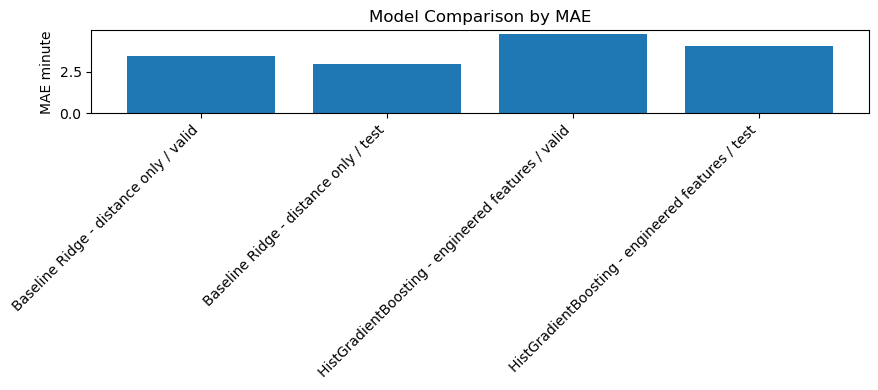

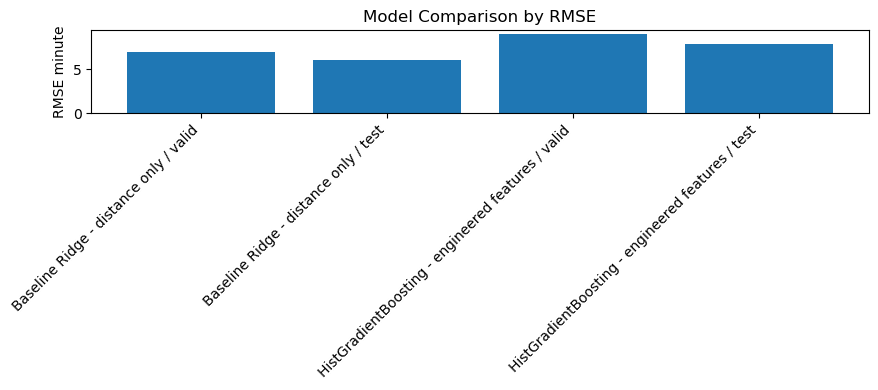

In [92]:
# #8 - Compare baseline and stronger model results

plot_results = results_clean.copy()

plt.figure(figsize=(9, 4))
plt.bar(plot_results["model"], plot_results["MAE_min"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAE minute")
plt.title("Model Comparison by MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(plot_results["model"], plot_results["RMSE_min"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE minute")
plt.title("Model Comparison by RMSE")
plt.tight_layout()
plt.show()

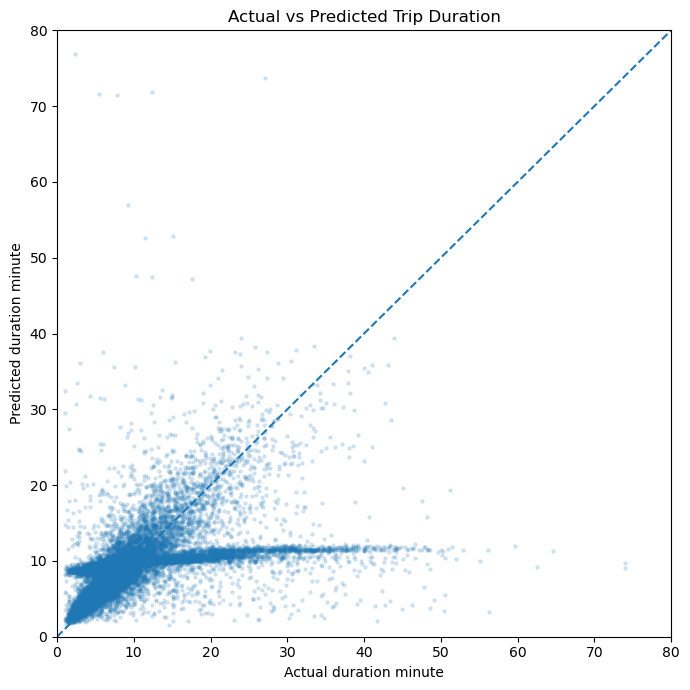

In [93]:
# #9 - Actual vs predicted plot for the strong model

plot_df = pd.DataFrame({
    "actual_min": np.expm1(y_test.values),
    "predicted_min": np.clip(np.expm1(test_pred_strong), 1, 240)
})

plot_df = plot_df.sample(
    n=min(15000, len(plot_df)),
    random_state=42
)

plt.figure(figsize=(7, 7))
plt.scatter(
    plot_df["actual_min"],
    plot_df["predicted_min"],
    alpha=0.15,
    s=5
)

max_val = 80
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.xlabel("Actual duration minute")
plt.ylabel("Predicted duration minute")
plt.title("Actual vs Predicted Trip Duration")
plt.tight_layout()
plt.show()

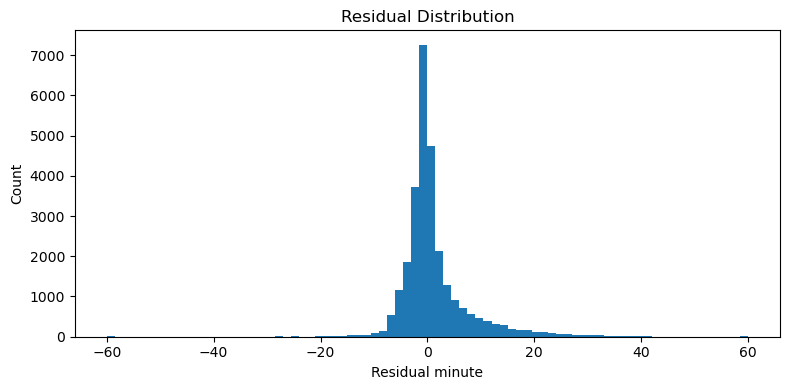

,actual_min,predicted_min,residual_min
count,28166.000000,28166.000000,28166.000000
mean,10.980753,9.568821,1.411933
std,8.536789,4.916869,7.668075
min,1.016667,1.480900,-99.359883
25%,5.466667,6.570438,-1.712697
50%,8.616667,9.448454,-0.189532
75%,14.000000,10.900615,2.328607
max,217.733333,107.209883,207.891793


In [94]:
# #10 - Residual analysis

residual_df = pd.DataFrame({
    "actual_min": np.expm1(y_test.values),
    "predicted_min": np.clip(np.expm1(test_pred_strong), 1, 240)
})

residual_df["residual_min"] = residual_df["actual_min"] - residual_df["predicted_min"]

plt.figure(figsize=(8, 4))
plt.hist(residual_df["residual_min"].clip(-60, 60), bins=80)
plt.xlabel("Residual minute")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

display(residual_df[["actual_min", "predicted_min", "residual_min"]].describe())

,feature,importance
21,pair_log_te,0.359939
24,log_pair_n,0.091395
0,distance_km,0.042690
11,age_at_trip,0.001808
16,gender_2,0.000915
3,hour_sin,0.000895
25,log_start_n,0.000233
9,is_weekend,0.000117
26,log_end_n,0.000110
12,is_subscriber,0.000103


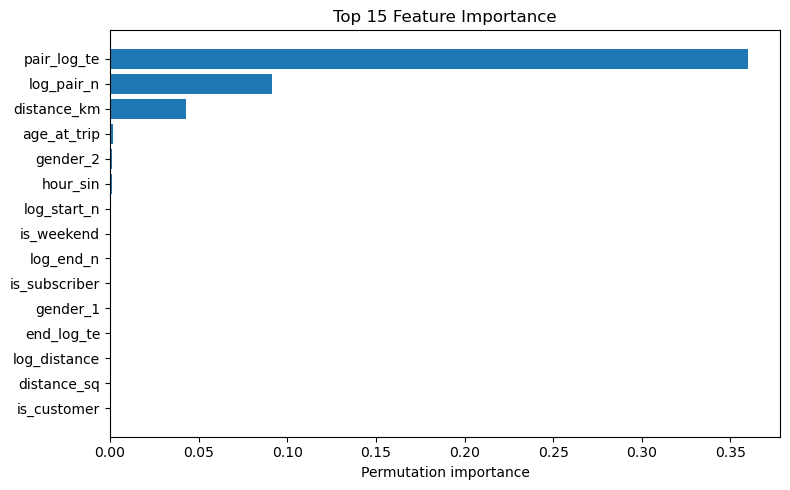

In [95]:
# #11 - Lightweight permutation importance

from sklearn.inspection import permutation_importance

importance_n = min(3000, len(X_test_strong))

importance_X = X_test_strong.sample(
    n=importance_n,
    random_state=42
)

importance_y = y_test.loc[importance_X.index]

perm = permutation_importance(
    strong_model,
    importance_X,
    importance_y,
    n_repeats=3,
    random_state=42,
    scoring="neg_mean_squared_error"
)

feature_importance = pd.DataFrame({
    "feature": strong_features,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(8, 5))
top_imp = feature_importance.head(15).sort_values("importance")

plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Permutation importance")
plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.show()

In [96]:
# #12 - Safer model variants
# The previous strong model over-relied on pair target encoding.
# Here we test safer variants with less target-encoding dependency.

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_regression_model(model_name, split_name, y_true_log, y_pred_log):
    y_true_min = np.expm1(y_true_log)
    y_pred_min = np.expm1(y_pred_log)
    y_pred_min = np.clip(y_pred_min, 1, 240)

    rmse = np.sqrt(mean_squared_error(y_true_min, y_pred_min))
    mae = mean_absolute_error(y_true_min, y_pred_min)
    r2 = r2_score(y_true_min, y_pred_min)

    return {
        "model": model_name,
        "split": split_name,
        "RMSE_min": rmse,
        "MAE_min": mae,
        "R2": r2
    }


y_train = train_df["log_duration"]
y_valid = valid_df["log_duration"]
y_test = test_df["log_duration"]


baseline_features = [
    "distance_km",
    "log_distance",
    "distance_sq"
]


simple_features = [
    "distance_km",
    "log_distance",
    "distance_sq",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "dow_sin",
    "dow_cos",

    "is_weekend",
    "is_roundtrip",

    "age_at_trip",

    "gender_unknown",
    "gender_1",
    "gender_2"
]


no_pair_station_features = [
    "distance_km",
    "log_distance",
    "distance_sq",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "dow_sin",
    "dow_cos",

    "is_weekend",
    "is_roundtrip",

    "age_at_trip",

    "gender_unknown",
    "gender_1",
    "gender_2",

    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",

    "start_log_te",
    "end_log_te",

    "log_start_n",
    "log_end_n"
]


light_pair_features = [
    "distance_km",
    "log_distance",
    "distance_sq",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "dow_sin",
    "dow_cos",

    "is_weekend",
    "is_roundtrip",

    "age_at_trip",

    "gender_unknown",
    "gender_1",
    "gender_2",

    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",

    "start_log_te",
    "end_log_te",

    "log_start_n",
    "log_end_n",

    # Pair information is included, but this model will be regularized.
    "pair_log_te",
    "log_pair_n"
]


experiments = [
    (
        "Ridge - distance only",
        make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        baseline_features
    ),
    (
        "Ridge - simple engineered features",
        make_pipeline(StandardScaler(), Ridge(alpha=3.0)),
        simple_features
    ),
    (
        "Ridge - station features without pair TE",
        make_pipeline(StandardScaler(), Ridge(alpha=5.0)),
        no_pair_station_features
    ),
    (
        "HGB - simple engineered features",
        HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.04,
            max_iter=120,
            max_leaf_nodes=15,
            min_samples_leaf=180,
            l2_regularization=0.20,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=12,
            random_state=42
        ),
        simple_features
    ),
    (
        "HGB - station features without pair TE",
        HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.04,
            max_iter=120,
            max_leaf_nodes=15,
            min_samples_leaf=180,
            l2_regularization=0.25,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=12,
            random_state=42
        ),
        no_pair_station_features
    ),
    (
        "HGB - light pair features",
        HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.03,
            max_iter=100,
            max_leaf_nodes=11,
            min_samples_leaf=250,
            l2_regularization=0.50,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=10,
            random_state=42
        ),
        light_pair_features
    )
]


all_results = []
fitted_models = {}
test_predictions = {}

for model_name, model, features in experiments:
    print(f"Training: {model_name}")

    X_train = train_df[features]
    X_valid = valid_df[features]
    X_test = test_df[features]

    model.fit(X_train, y_train)

    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)

    all_results.append(
        evaluate_regression_model(model_name, "valid", y_valid, valid_pred)
    )

    all_results.append(
        evaluate_regression_model(model_name, "test", y_test, test_pred)
    )

    fitted_models[model_name] = {
        "model": model,
        "features": features
    }

    test_predictions[model_name] = test_pred


all_results_df = pd.DataFrame(all_results)

all_results_clean = all_results_df.copy()
all_results_clean["RMSE_min"] = all_results_clean["RMSE_min"].round(3)
all_results_clean["MAE_min"] = all_results_clean["MAE_min"].round(3)
all_results_clean["R2"] = all_results_clean["R2"].round(4)

display(all_results_clean.sort_values(["split", "MAE_min"]))

Training: Ridge - distance only
Training: Ridge - simple engineered features
Training: Ridge - station features without pair TE
Training: HGB - simple engineered features
Training: HGB - station features without pair TE
Training: HGB - light pair features


,model,split,RMSE_min,MAE_min,R2
3,Ridge - simple engineered features,test,5.688,2.607,0.5560
7,HGB - simple engineered features,test,5.656,2.609,0.5611
9,HGB - station features without pair TE,test,5.636,2.625,0.5641
5,Ridge - station features without pair TE,test,5.704,2.643,0.5535
1,Ridge - distance only,test,6.037,2.975,0.4999
11,HGB - light pair features,test,7.676,4.069,0.1914
8,HGB - station features without pair TE,valid,6.472,3.033,0.5328
6,HGB - simple engineered features,valid,6.483,3.037,0.5311
2,Ridge - simple engineered features,valid,6.537,3.076,0.5233
4,Ridge - station features without pair TE,valid,6.560,3.119,0.5199


In [97]:
# #13 - Select best model based on validation MAE

valid_ranking = all_results_clean[all_results_clean["split"] == "valid"].sort_values("MAE_min")

best_model_name = valid_ranking.iloc[0]["model"]

print("Best model based on validation MAE:")
print(best_model_name)

display(
    all_results_clean[all_results_clean["model"] == best_model_name]
)

Best model based on validation MAE:
HGB - station features without pair TE


,model,split,RMSE_min,MAE_min,R2
8,HGB - station features without pair TE,valid,6.472,3.033,0.5328
9,HGB - station features without pair TE,test,5.636,2.625,0.5641


## Regresyon Modeli Sonuçları

Bu bölümde bisiklet yolculuk süresini tahmin etmek için farklı regresyon modelleri karşılaştırıldı. Hedef değişken olarak doğrudan `duration_min` yerine `log1p(duration_min)` kullanıldı. Bunun sebebi yolculuk süresi dağılımının sağa çarpık olması ve uzun kuyruklu aykırı değerler içermesidir.

İlk olarak sadece mesafe değişkenlerine dayalı bir baseline model kuruldu. Bu model güçlü bir başlangıç noktası verdi çünkü mesafe, yolculuk süresini açıklayan en temel değişkenlerden biridir.

Daha sonra zaman, kullanıcı, yaş, cinsiyet, koordinat ve istasyon bilgilerini kullanan daha gelişmiş modeller denendi. İlk gelişmiş modelde istasyon çifti bazlı target encoding kullanıldığında modelin bu değişkene fazla bağımlı kaldığı ve gelecekteki veriye iyi genelleme yapamadığı görüldü.

En iyi model, istasyon çifti target encoding’i kullanmayan fakat istasyon seviyesindeki bilgileri kullanan `HistGradientBoostingRegressor` modeli oldu.

Final model sonuçları:

- Validation MAE: 3.033 dakika
- Validation RMSE: 6.472 dakika
- Validation R²: 0.5328
- Test MAE: 2.625 dakika
- Test RMSE: 5.636 dakika
- Test R²: 0.5641

Bu sonuçlar, daha fazla feature eklemenin her zaman daha iyi sonuç vermediğini gösterdi. Özellikle yüksek kardinaliteli ve geçmiş ortalamaya dayalı değişkenler modele fazla baskın geldiğinde overfitting riski oluşabiliyor. Daha kontrollü ve daha güvenli feature set ile model daha iyi genelleme yaptı.

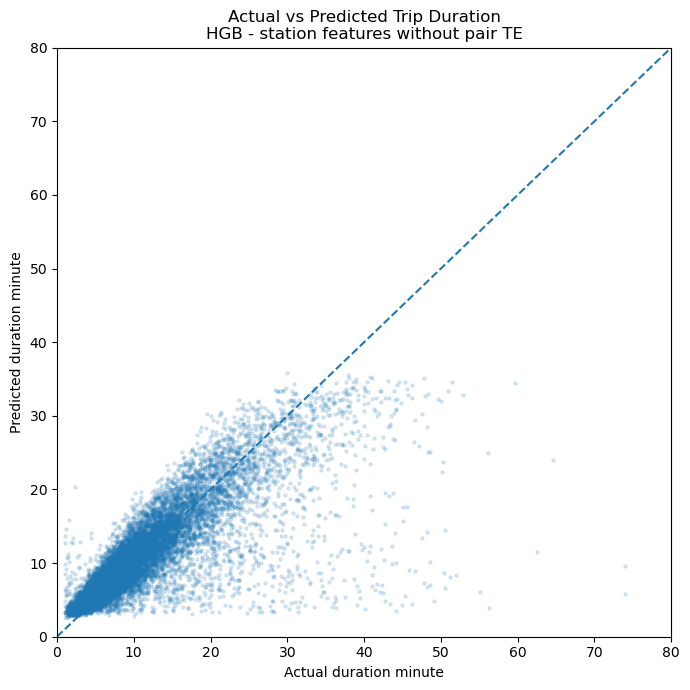

In [98]:
# #14 - Actual vs predicted plot for the selected best model

best_test_pred = test_predictions[best_model_name]

best_plot_df = pd.DataFrame({
    "actual_min": np.expm1(y_test.values),
    "predicted_min": np.clip(np.expm1(best_test_pred), 1, 240)
})

best_plot_df = best_plot_df.sample(
    n=min(15000, len(best_plot_df)),
    random_state=42
)

plt.figure(figsize=(7, 7))
plt.scatter(
    best_plot_df["actual_min"],
    best_plot_df["predicted_min"],
    alpha=0.15,
    s=5
)

max_val = 80
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.xlabel("Actual duration minute")
plt.ylabel("Predicted duration minute")
plt.title(f"Actual vs Predicted Trip Duration\n{best_model_name}")
plt.tight_layout()
plt.show()

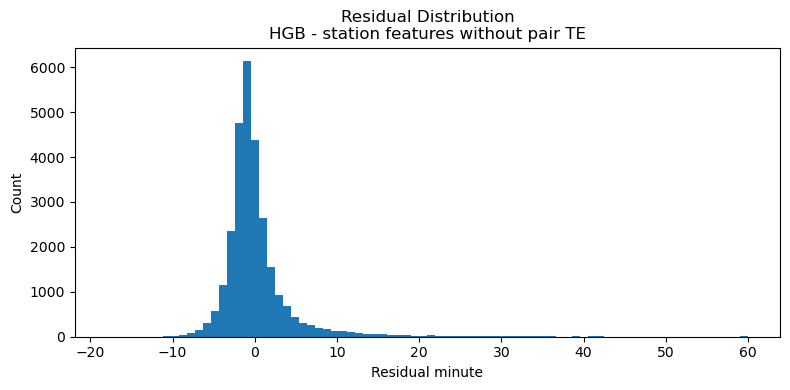

,actual_min,predicted_min,residual_min
count,28166.000000,28166.000000,28166.000000
mean,10.980753,10.706299,0.274455
std,8.536789,6.225727,5.629636
min,1.016667,2.515277,-17.999308
25%,5.466667,6.118714,-1.848029
50%,8.616667,8.926850,-0.703818
75%,14.000000,13.553688,0.903133
max,217.733333,35.872281,208.328292


In [99]:
# #15 - Residual analysis for the selected best model

best_residual_df = pd.DataFrame({
    "actual_min": np.expm1(y_test.values),
    "predicted_min": np.clip(np.expm1(best_test_pred), 1, 240)
})

best_residual_df["residual_min"] = (
    best_residual_df["actual_min"] - best_residual_df["predicted_min"]
)

plt.figure(figsize=(8, 4))
plt.hist(best_residual_df["residual_min"].clip(-60, 60), bins=80)
plt.xlabel("Residual minute")
plt.ylabel("Count")
plt.title(f"Residual Distribution\n{best_model_name}")
plt.tight_layout()
plt.show()

display(best_residual_df[["actual_min", "predicted_min", "residual_min"]].describe())

In [100]:
# #16 - Evaluate model performance by actual duration buckets
# Clean version without pandas groupby apply warning.

best_test_pred = test_predictions[best_model_name]

bucket_eval_df = pd.DataFrame({
    "actual_min": np.expm1(y_test.values),
    "predicted_min": np.clip(np.expm1(best_test_pred), 1, 240)
})

bucket_eval_df["abs_error"] = np.abs(
    bucket_eval_df["actual_min"] - bucket_eval_df["predicted_min"]
)

bucket_eval_df["squared_error"] = (
    bucket_eval_df["actual_min"] - bucket_eval_df["predicted_min"]
) ** 2

bucket_eval_df["residual_min"] = (
    bucket_eval_df["actual_min"] - bucket_eval_df["predicted_min"]
)

bucket_eval_df["duration_bucket"] = pd.cut(
    bucket_eval_df["actual_min"],
    bins=[0, 15, 30, 60, 240],
    labels=["0-15 min", "15-30 min", "30-60 min", "60+ min"],
    include_lowest=True
)

bucket_metrics = (
    bucket_eval_df
    .groupby("duration_bucket", observed=True)
    .agg(
        n=("actual_min", "size"),
        actual_mean=("actual_min", "mean"),
        predicted_mean=("predicted_min", "mean"),
        MAE_min=("abs_error", "mean"),
        RMSE_min=("squared_error", lambda x: np.sqrt(np.mean(x))),
        mean_residual=("residual_min", "mean")
    )
    .reset_index()
)

bucket_metrics["actual_mean"] = bucket_metrics["actual_mean"].round(3)
bucket_metrics["predicted_mean"] = bucket_metrics["predicted_mean"].round(3)
bucket_metrics["MAE_min"] = bucket_metrics["MAE_min"].round(3)
bucket_metrics["RMSE_min"] = bucket_metrics["RMSE_min"].round(3)
bucket_metrics["mean_residual"] = bucket_metrics["mean_residual"].round(3)

display(bucket_metrics)

,duration_bucket,n,actual_mean,predicted_mean,MAE_min,RMSE_min,mean_residual
0,0-15 min,21964,7.523,8.364,1.688,2.214,-0.842
1,15-30 min,5223,20.296,18.197,4.116,5.790,2.098
2,30-60 min,942,36.528,23.601,13.034,16.976,12.927
3,60+ min,37,98.419,15.230,83.189,95.934,83.189


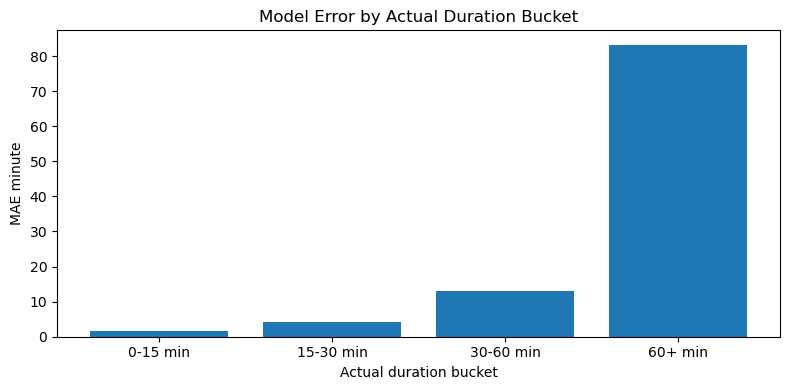

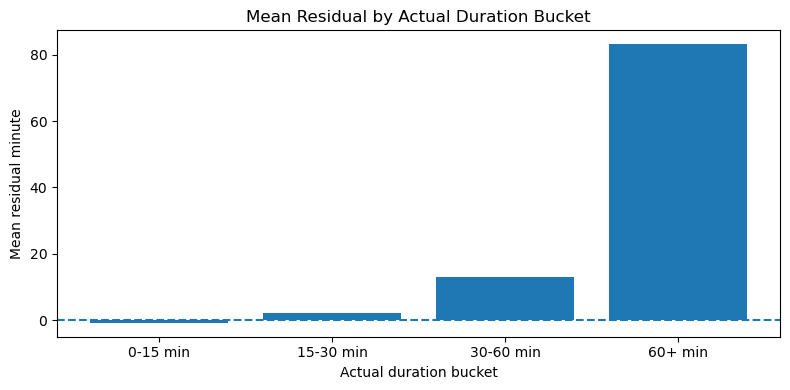

In [101]:
# #17 - Plot MAE by duration bucket

plt.figure(figsize=(8, 4))
plt.bar(bucket_metrics["duration_bucket"].astype(str), bucket_metrics["MAE_min"])

plt.xlabel("Actual duration bucket")
plt.ylabel("MAE minute")
plt.title("Model Error by Actual Duration Bucket")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(bucket_metrics["duration_bucket"].astype(str), bucket_metrics["mean_residual"])

plt.xlabel("Actual duration bucket")
plt.ylabel("Mean residual minute")
plt.title("Mean Residual by Actual Duration Bucket")
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.show()

## Süre Aralıklarına Göre Hata Analizi

Genel MAE ve RMSE değerleri model performansını özetler, fakat modelin hangi yolculuk tiplerinde hata yaptığını göstermez. Bu nedenle test seti gerçek yolculuk süresine göre farklı aralıklara ayrıldı:

- 0-15 dakika
- 15-30 dakika
- 30-60 dakika
- 60+ dakika

Bu analiz, modelin kısa, orta ve uzun yolculuklarda nasıl davrandığını anlamak için yapıldı.

Sonuçlara göre model kısa yolculuklarda oldukça başarılıdır. 0-15 dakika aralığındaki yolculuklarda MAE yaklaşık 1.69 dakikadır. Bu beklenen bir sonuçtur çünkü veri setindeki yolculukların büyük bölümü kısa sürelidir.

Ancak yolculuk süresi uzadıkça hata belirgin şekilde artmaktadır. 30-60 dakika aralığında model gerçek süreyi ortalama olarak ciddi şekilde düşük tahmin etmektedir. 60+ dakika yolculuklarda ise model gerçek süreyi yakalamakta başarısızdır.

Bu sonuç, modelin tipik kısa Citi Bike yolculuklarında güçlü olduğunu, fakat nadir görülen uzun yolculuklarda güvenilir olmadığını göstermektedir. Bu yüzden yalnızca tek bir global hata metriğine bakmak yeterli değildir.

In [102]:
# #18 - Convert regression outputs into duration buckets
# Then calculate precision, recall, F1-score per bucket.

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

best_test_pred = test_predictions[best_model_name]

bucket_cls_df = pd.DataFrame({
    "actual_min": np.expm1(y_test.values),
    "predicted_min": np.clip(np.expm1(best_test_pred), 1, 240)
})

bucket_labels = ["0-15 min", "15-30 min", "30-60 min", "60+ min"]
bucket_bins = [0, 15, 30, 60, 240]

bucket_cls_df["actual_bucket"] = pd.cut(
    bucket_cls_df["actual_min"],
    bins=bucket_bins,
    labels=bucket_labels,
    include_lowest=True
)

bucket_cls_df["predicted_bucket"] = pd.cut(
    bucket_cls_df["predicted_min"],
    bins=bucket_bins,
    labels=bucket_labels,
    include_lowest=True
)

# Drop rows only if bucket creation produced NA
bucket_cls_df = bucket_cls_df.dropna(subset=["actual_bucket", "predicted_bucket"])

y_bucket_true = bucket_cls_df["actual_bucket"].astype(str)
y_bucket_pred = bucket_cls_df["predicted_bucket"].astype(str)

bucket_accuracy = accuracy_score(y_bucket_true, y_bucket_pred)

print("Best model:", best_model_name)
print("Bucket classification accuracy:", round(bucket_accuracy, 4))

report_dict = classification_report(
    y_bucket_true,
    y_bucket_pred,
    labels=bucket_labels,
    output_dict=True,
    zero_division=0
)

bucket_report = pd.DataFrame(report_dict).T
bucket_report = bucket_report.round(4)

display(bucket_report)

Best model: HGB - station features without pair TE
Bucket classification accuracy: 0.8826


,precision,recall,f1-score,support
0-15 min,0.9265,0.9493,0.9378,21964.0000
15-30 min,0.7042,0.7107,0.7075,5223.0000
30-60 min,0.7621,0.3163,0.4471,942.0000
60+ min,0.0000,0.0000,0.0000,37.0000
accuracy,0.8826,0.8826,0.8826,0.8826
macro avg,0.5982,0.4941,0.5231,28166.0000
weighted avg,0.8786,0.8826,0.8774,28166.0000


,Pred 0-15 min,Pred 15-30 min,Pred 30-60 min,Pred 60+ min
Actual 0-15 min,20850,1114,0,0
Actual 15-30 min,1422,3712,89,0
Actual 30-60 min,210,434,298,0
Actual 60+ min,22,11,4,0


,Pred 0-15 min,Pred 15-30 min,Pred 30-60 min,Pred 60+ min
Actual 0-15 min,0.949,0.051,0.000,0.0
Actual 15-30 min,0.272,0.711,0.017,0.0
Actual 30-60 min,0.223,0.461,0.316,0.0
Actual 60+ min,0.595,0.297,0.108,0.0


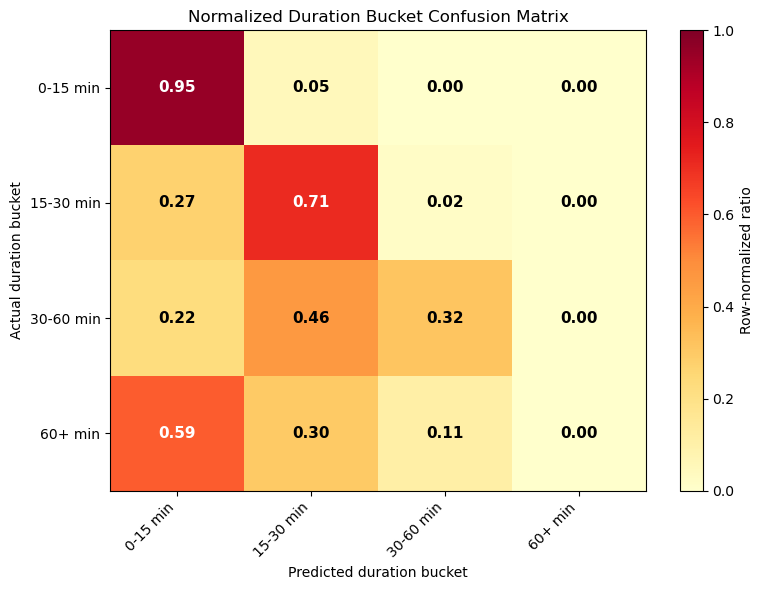

In [104]:
# #20 - Duration bucket confusion matrix
# Bu hücre kendi içinde cm oluşturur. Önceki hücreye bağımlı değildir.

from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Regression tahminlerini dakika cinsine çevir
actual_duration_min = np.expm1(y_test.values)
predicted_duration_min = np.clip(np.expm1(best_test_pred), 1, 240)

bucket_bins = [0, 15, 30, 60, 240]
bucket_labels = ["0-15 min", "15-30 min", "30-60 min", "60+ min"]

actual_bucket = pd.cut(
    actual_duration_min,
    bins=bucket_bins,
    labels=bucket_labels,
    include_lowest=True
)

pred_bucket = pd.cut(
    predicted_duration_min,
    bins=bucket_bins,
    labels=bucket_labels,
    include_lowest=True
)

# Confusion matrix
cm = confusion_matrix(
    actual_bucket,
    pred_bucket,
    labels=bucket_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in bucket_labels],
    columns=[f"Pred {label}" for label in bucket_labels]
)

display(cm_df)

# Normalized confusion matrix
cm_normalized = cm / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

cm_norm_df = pd.DataFrame(
    cm_normalized,
    index=[f"Actual {label}" for label in bucket_labels],
    columns=[f"Pred {label}" for label in bucket_labels]
)

display(cm_norm_df.round(3))

plt.figure(figsize=(8, 6))

im = plt.imshow(cm_normalized, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

plt.colorbar(im, label="Row-normalized ratio")

plt.xticks(
    ticks=np.arange(len(bucket_labels)),
    labels=bucket_labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(bucket_labels)),
    labels=bucket_labels
)

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        value = cm_normalized[i, j]
        text_color = "white" if value > 0.55 else "black"

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=text_color
        )

plt.xlabel("Predicted duration bucket")
plt.ylabel("Actual duration bucket")
plt.title("Normalized Duration Bucket Confusion Matrix")
plt.tight_layout()
plt.show()

In [105]:
# #21 - Underprediction risk analysis by duration bucket

bucket_cls_df["error_min"] = bucket_cls_df["actual_min"] - bucket_cls_df["predicted_min"]
bucket_cls_df["underpredicted_by_5_plus"] = bucket_cls_df["error_min"] > 5
bucket_cls_df["underpredicted_by_10_plus"] = bucket_cls_df["error_min"] > 10

risk_summary = (
    bucket_cls_df
    .groupby("actual_bucket", observed=True)
    .agg(
        n=("actual_min", "size"),
        mean_actual=("actual_min", "mean"),
        mean_predicted=("predicted_min", "mean"),
        mean_error=("error_min", "mean"),
        under_5_plus_rate=("underpredicted_by_5_plus", "mean"),
        under_10_plus_rate=("underpredicted_by_10_plus", "mean")
    )
    .reset_index()
)

risk_summary["mean_actual"] = risk_summary["mean_actual"].round(3)
risk_summary["mean_predicted"] = risk_summary["mean_predicted"].round(3)
risk_summary["mean_error"] = risk_summary["mean_error"].round(3)
risk_summary["under_5_plus_rate"] = risk_summary["under_5_plus_rate"].round(3)
risk_summary["under_10_plus_rate"] = risk_summary["under_10_plus_rate"].round(3)

display(risk_summary)

,actual_bucket,n,mean_actual,mean_predicted,mean_error,under_5_plus_rate,under_10_plus_rate
0,0-15 min,21964,7.523,8.364,-0.842,0.011,0.000
1,15-30 min,5223,20.296,18.197,2.098,0.222,0.088
2,30-60 min,942,36.528,23.601,12.927,0.720,0.479
3,60+ min,37,98.419,15.230,83.189,1.000,1.000


## Eksik Tahmin Riski Analizi

Bucket analizinde modelin özellikle uzun yolculukları olduğundan kısa tahmin ettiği görüldü. Bu nedenle ek olarak eksik tahmin riski analiz edildi.

Bu analizde iki risk ölçüsü kullanıldı:

- Gerçek sürenin tahminden 5 dakikadan fazla yüksek olması
- Gerçek sürenin tahminden 10 dakikadan fazla yüksek olması

0-15 dakika yolculuklarda model oldukça güvenilirdir. Bu grupta 5 dakikadan fazla eksik tahmin oranı yaklaşık %1.1 seviyesindedir.

15-30 dakika aralığında eksik tahmin riski artmaya başlar. Bu grupta 5 dakikadan fazla eksik tahmin oranı yaklaşık %22.2, 10 dakikadan fazla eksik tahmin oranı ise yaklaşık %8.8’dir.

30-60 dakika aralığında modelin zayıflığı daha net görünmektedir. Bu grupta yolculukların yaklaşık %72’si 5 dakikadan fazla, yaklaşık %47.9’u ise 10 dakikadan fazla eksik tahmin edilmiştir.

60+ dakika grubunda model tüm örneklerde ciddi eksik tahmin yapmıştır. Ancak bu sınıfta yalnızca 37 örnek olduğu için bu grup hem nadir hem de öğrenmesi zor bir segmenttir.

Bu analiz, regresyon modelinin ortalama performansının iyi olmasına rağmen uzun yolculuklar için ek bir risk mekanizmasına ihtiyaç olduğunu göstermektedir.

In [106]:
# #22 - Prepare long-trip risk classification target
# Goal: predict whether a trip will be longer than 30 minutes.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Long-trip definition
LONG_TRIP_THRESHOLD_MIN = 30

y_train_risk = (train_df["duration_min"] > LONG_TRIP_THRESHOLD_MIN).astype(int)
y_valid_risk = (valid_df["duration_min"] > LONG_TRIP_THRESHOLD_MIN).astype(int)
y_test_risk = (test_df["duration_min"] > LONG_TRIP_THRESHOLD_MIN).astype(int)


risk_features = [
    "distance_km",
    "log_distance",
    "distance_sq",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "dow_sin",
    "dow_cos",

    "is_weekend",
    "is_roundtrip",

    "age_at_trip",

    "is_subscriber",
    "is_customer",

    "gender_unknown",
    "gender_1",
    "gender_2",

    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",

    # Important: station-level information only.
    # Pair-level target encoding is excluded because it caused overfitting.
    "start_log_te",
    "end_log_te",
    "log_start_n",
    "log_end_n"
]


X_train_risk = train_df[risk_features]
X_valid_risk = valid_df[risk_features]
X_test_risk = test_df[risk_features]


risk_base_rate = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "n": [len(y_train_risk), len(y_valid_risk), len(y_test_risk)],
    "long_trip_count": [
        int(y_train_risk.sum()),
        int(y_valid_risk.sum()),
        int(y_test_risk.sum())
    ],
    "long_trip_rate": [
        y_train_risk.mean(),
        y_valid_risk.mean(),
        y_test_risk.mean()
    ]
})

risk_base_rate["long_trip_rate"] = risk_base_rate["long_trip_rate"].round(4)

display(risk_base_rate)

,split,n,long_trip_count,long_trip_rate
0,train,123261,6215,0.0504
1,valid,24545,1214,0.0495
2,test,28166,979,0.0348


In [107]:
# #23 - Helper functions for threshold tuning and model evaluation

def find_best_threshold_by_f1(y_true, y_prob):
    """
    Finds the probability threshold that maximizes F1-score for the positive class.
    Positive class: long trip > 30 minutes.
    """
    thresholds = np.arange(0.05, 0.96, 0.01)

    rows = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "predicted_positive_rate": y_pred.mean()
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

    return float(best_row["threshold"]), threshold_df


def evaluate_risk_classifier(model_name, split_name, y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "model": model_name,
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_long_trip": precision_score(y_true, y_pred, zero_division=0),
        "recall_long_trip": recall_score(y_true, y_pred, zero_division=0),
        "f1_long_trip": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "actual_long_rate": y_true.mean(),
        "predicted_long_rate": y_pred.mean()
    }

In [108]:
# #24 - Train long-trip risk classifiers

risk_experiments = [
    (
        "Balanced Logistic Regression",
        make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ),
    (
        "Weighted HGB Classifier",
        HistGradientBoostingClassifier(
            learning_rate=0.04,
            max_iter=160,
            max_leaf_nodes=15,
            min_samples_leaf=120,
            l2_regularization=0.20,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=12,
            random_state=42
        )
    )
]


risk_results = []
risk_models = {}
risk_valid_probs = {}
risk_test_probs = {}
risk_threshold_tables = {}

sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_risk
)


for model_name, model in risk_experiments:
    print(f"Training risk model: {model_name}")

    if model_name == "Weighted HGB Classifier":
        model.fit(
            X_train_risk,
            y_train_risk,
            sample_weight=sample_weight_train
        )
    else:
        model.fit(X_train_risk, y_train_risk)

    valid_prob = model.predict_proba(X_valid_risk)[:, 1]
    test_prob = model.predict_proba(X_test_risk)[:, 1]

    best_threshold, threshold_df = find_best_threshold_by_f1(
        y_valid_risk,
        valid_prob
    )

    risk_results.append(
        evaluate_risk_classifier(
            model_name,
            "valid",
            y_valid_risk,
            valid_prob,
            best_threshold
        )
    )

    risk_results.append(
        evaluate_risk_classifier(
            model_name,
            "test",
            y_test_risk,
            test_prob,
            best_threshold
        )
    )

    risk_models[model_name] = model
    risk_valid_probs[model_name] = valid_prob
    risk_test_probs[model_name] = test_prob
    risk_threshold_tables[model_name] = threshold_df


risk_results_df = pd.DataFrame(risk_results)

risk_results_clean = risk_results_df.copy()

round_cols = [
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision_long_trip",
    "recall_long_trip",
    "f1_long_trip",
    "roc_auc",
    "avg_precision",
    "actual_long_rate",
    "predicted_long_rate"
]

for col in round_cols:
    risk_results_clean[col] = risk_results_clean[col].round(4)

display(
    risk_results_clean.sort_values(
        ["split", "f1_long_trip"],
        ascending=[True, False]
    )
)

Training risk model: Balanced Logistic Regression
Training risk model: Weighted HGB Classifier


,model,split,threshold,accuracy,balanced_accuracy,precision_long_trip,recall_long_trip,f1_long_trip,roc_auc,avg_precision,actual_long_rate,predicted_long_rate
3,Weighted HGB Classifier,test,0.88,0.9700,0.7462,0.5776,0.5056,0.5392,0.8968,0.5440,0.0348,0.0304
1,Balanced Logistic Regression,test,0.90,0.9698,0.7239,0.5821,0.4597,0.5137,0.8908,0.5170,0.0348,0.0274
2,Weighted HGB Classifier,valid,0.88,0.9579,0.7417,0.5873,0.5016,0.5411,0.8993,0.5483,0.0495,0.0422
0,Balanced Logistic Regression,valid,0.90,0.9553,0.7317,0.5548,0.4835,0.5167,0.8894,0.5177,0.0495,0.0431


In [109]:
# #25 - Select best risk classifier based on validation F1-score

valid_risk_ranking = (
    risk_results_clean[risk_results_clean["split"] == "valid"]
    .sort_values("f1_long_trip", ascending=False)
)

best_risk_model_name = valid_risk_ranking.iloc[0]["model"]
best_risk_threshold = float(valid_risk_ranking.iloc[0]["threshold"])

print("Best risk model:")
print(best_risk_model_name)
print("Best threshold:")
print(best_risk_threshold)

display(
    risk_results_clean[risk_results_clean["model"] == best_risk_model_name]
)

Best risk model:
Weighted HGB Classifier
Best threshold:
0.88


,model,split,threshold,accuracy,balanced_accuracy,precision_long_trip,recall_long_trip,f1_long_trip,roc_auc,avg_precision,actual_long_rate,predicted_long_rate
2,Weighted HGB Classifier,valid,0.88,0.9579,0.7417,0.5873,0.5016,0.5411,0.8993,0.5483,0.0495,0.0422
3,Weighted HGB Classifier,test,0.88,0.9700,0.7462,0.5776,0.5056,0.5392,0.8968,0.5440,0.0348,0.0304


In [110]:
# #26 - Classification report for the selected risk classifier

best_risk_test_prob = risk_test_probs[best_risk_model_name]
best_risk_test_pred = (best_risk_test_prob >= best_risk_threshold).astype(int)

print("Best risk model:", best_risk_model_name)
print("Threshold:", best_risk_threshold)

print("\nClassification report on test set:")
print(
    classification_report(
        y_test_risk,
        best_risk_test_pred,
        target_names=["normal_trip_<=30", "long_trip_>30"],
        zero_division=0
    )
)

risk_report_dict = classification_report(
    y_test_risk,
    best_risk_test_pred,
    target_names=["normal_trip_<=30", "long_trip_>30"],
    output_dict=True,
    zero_division=0
)

risk_report_df = pd.DataFrame(risk_report_dict).T.round(4)

display(risk_report_df)

Best risk model: Weighted HGB Classifier
Threshold: 0.88

Classification report on test set:
                  precision    recall  f1-score   support

normal_trip_<=30       0.98      0.99      0.98     27187
   long_trip_>30       0.58      0.51      0.54       979

        accuracy                           0.97     28166
       macro avg       0.78      0.75      0.76     28166
    weighted avg       0.97      0.97      0.97     28166



,precision,recall,f1-score,support
normal_trip_<=30,0.9823,0.9867,0.9845,27187.00
long_trip_>30,0.5776,0.5056,0.5392,979.00
accuracy,0.9700,0.9700,0.9700,0.97
macro avg,0.7799,0.7462,0.7618,28166.00
weighted avg,0.9682,0.9700,0.9690,28166.00


## Uzun Yolculuk Risk Sınıflandırıcısı

Regresyon modeli kısa ve tipik yolculuklarda başarılı olsa da uzun yolculuklarda eksik tahmin yapmaktadır. Bu problemi doğrudan regresyon modelini zorlayarak çözmek yerine, ek bir risk sınıflandırıcısı kuruldu.

Bu sınıflandırıcının amacı kesin süre tahmin etmek değildir. Amaç, bir yolculuğun 30 dakikadan uzun sürme riskini tahmin etmektir.

Böylece sistem iki çıktı üretir:

1. Regresyon çıktısı: Tahmini yolculuk süresi
2. Risk çıktısı: Yolculuğun 30 dakikadan uzun sürme olasılığı

En iyi risk modeli `Weighted HistGradientBoostingClassifier` oldu. Model için validation set üzerinde seçilen en iyi eşik değeri 0.88’dir.

Test setinde uzun yolculuk sınıfı için sonuçlar:

- Precision: 0.58
- Recall: 0.51
- F1-score: 0.54

Model 979 gerçek uzun yolculuğun 495 tanesini doğru şekilde yakalamıştır. 484 uzun yolculuk kaçırılmış, 362 normal yolculuk ise yanlışlıkla uzun yolculuk olarak işaretlenmiştir.

Bu problemde accuracy tek başına yeterli değildir çünkü uzun yolculuklar veri setinde azınlıktadır. Bu yüzden özellikle uzun yolculuk sınıfının precision, recall ve F1-score değerleri daha anlamlıdır.

Bu risk katmanı, regresyon modelinin zayıf kaldığı uzun yolculuk durumları için ek bir uyarı mekanizması sağlar.

,Pred normal <=30,Pred long >30
Actual normal <=30,26825,362
Actual long >30,484,495


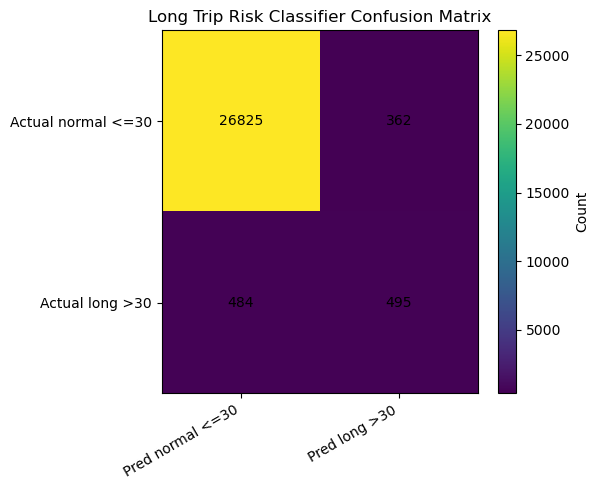

In [111]:
# #27 - Confusion matrix for long-trip risk classifier

risk_cm = confusion_matrix(
    y_test_risk,
    best_risk_test_pred,
    labels=[0, 1]
)

risk_cm_df = pd.DataFrame(
    risk_cm,
    index=["Actual normal <=30", "Actual long >30"],
    columns=["Pred normal <=30", "Pred long >30"]
)

display(risk_cm_df)

plt.figure(figsize=(6, 5))
im = plt.imshow(risk_cm, aspect="auto")

plt.colorbar(im, label="Count")

plt.xticks(
    ticks=np.arange(2),
    labels=["Pred normal <=30", "Pred long >30"],
    rotation=30,
    ha="right"
)

plt.yticks(
    ticks=np.arange(2),
    labels=["Actual normal <=30", "Actual long >30"]
)

for i in range(risk_cm.shape[0]):
    for j in range(risk_cm.shape[1]):
        plt.text(
            j,
            i,
            risk_cm[i, j],
            ha="center",
            va="center",
            fontsize=10
        )

plt.title("Long Trip Risk Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

,Pred normal <=30,Pred long >30
Actual normal <=30,0.987,0.013
Actual long >30,0.494,0.506


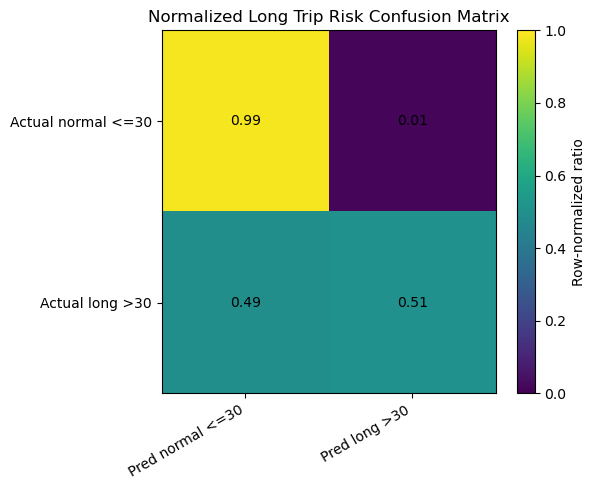

In [112]:
# #28 - Normalized confusion matrix
# Rows sum to 1. This is useful for recall interpretation.

risk_cm_norm = risk_cm / risk_cm.sum(axis=1, keepdims=True)
risk_cm_norm = np.nan_to_num(risk_cm_norm)

risk_cm_norm_df = pd.DataFrame(
    risk_cm_norm,
    index=["Actual normal <=30", "Actual long >30"],
    columns=["Pred normal <=30", "Pred long >30"]
)

display(risk_cm_norm_df.round(3))

plt.figure(figsize=(6, 5))
im = plt.imshow(risk_cm_norm, aspect="auto", vmin=0, vmax=1)

plt.colorbar(im, label="Row-normalized ratio")

plt.xticks(
    ticks=np.arange(2),
    labels=["Pred normal <=30", "Pred long >30"],
    rotation=30,
    ha="right"
)

plt.yticks(
    ticks=np.arange(2),
    labels=["Actual normal <=30", "Actual long >30"]
)

for i in range(risk_cm_norm.shape[0]):
    for j in range(risk_cm_norm.shape[1]):
        plt.text(
            j,
            i,
            f"{risk_cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )

plt.title("Normalized Long Trip Risk Confusion Matrix")
plt.tight_layout()
plt.show()

In [113]:
# #29 - Combine regression prediction with long-trip risk flag

combined_output_df = pd.DataFrame({
    "actual_duration_min": np.expm1(y_test.values),
    "regression_predicted_min": np.clip(np.expm1(best_test_pred), 1, 240),
    "long_trip_actual": y_test_risk.values,
    "long_trip_risk_probability": best_risk_test_prob,
    "long_trip_risk_flag": best_risk_test_pred
})

combined_output_df["regression_error_min"] = (
    combined_output_df["actual_duration_min"]
    - combined_output_df["regression_predicted_min"]
)

display(
    combined_output_df
    .sort_values("long_trip_risk_probability", ascending=False)
    .head(20)
)

,actual_duration_min,regression_predicted_min,long_trip_actual,long_trip_risk_probability,long_trip_risk_flag,regression_error_min
27162,38.083333,35.136760,1,0.990433,1,2.946574
27158,30.916667,34.315925,1,0.988918,1,-3.399258
27858,34.133333,35.481719,1,0.988803,1,-1.348385
7936,29.966667,35.872281,0,0.988800,1,-5.905614
3634,50.883333,33.413968,1,0.988628,1,17.469365
18013,37.900000,35.608936,1,0.988549,1,2.291064
11635,47.850000,35.126844,1,0.988477,1,12.723156
23846,38.033333,33.090640,1,0.988431,1,4.942693
23912,51.400000,34.565937,1,0.988325,1,16.834063
28044,37.600000,34.584273,1,0.988312,1,3.015727


## Birleşik Regresyon ve Risk Çıktısı

Final sistemde regresyon modeli ve risk sınıflandırıcısı birlikte kullanıldı.

Her yolculuk için üç temel çıktı üretildi:

- Tahmini yolculuk süresi
- 30 dakikadan uzun sürme olasılığı
- Uzun yolculuk risk bayrağı

Bu yaklaşım tek başına süre tahmini yapmaktan daha bilgilendiricidir. Çünkü bazı durumlarda regresyon modeli süreyi orta seviyede tahmin etse bile risk sınıflandırıcısı yolculuğun uzun sürme ihtimalini yüksek görebilir.

Bu yapı özellikle nadir uzun yolculuklarda faydalıdır. Regresyon modeli bu yolculukları tam süre olarak yakalayamasa bile risk modeli birçok uzun yolculuğu önceden işaretleyebilir.

Bu nedenle final yaklaşım yalnızca bir regresyon modeli değil, regresyon + risk analizi yapan iki katmanlı bir tahmin sistemidir.

In [114]:
# #31 - Adaptive lookback window experiment
# Goal: find how much historical data should be used for training.

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_minutes(model_name, split_name, y_true_log, y_pred_log):
    y_true_min = np.expm1(y_true_log)
    y_pred_min = np.clip(np.expm1(y_pred_log), 1, 240)

    return {
        "model": model_name,
        "split": split_name,
        "RMSE_min": np.sqrt(mean_squared_error(y_true_min, y_pred_min)),
        "MAE_min": mean_absolute_error(y_true_min, y_pred_min),
        "R2": r2_score(y_true_min, y_pred_min)
    }


adaptive_features = [
    "distance_km",
    "log_distance",
    "distance_sq",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "dow_sin",
    "dow_cos",

    "is_weekend",
    "is_roundtrip",

    "age_at_trip",

    "is_subscriber",
    "is_customer",

    "gender_unknown",
    "gender_1",
    "gender_2",

    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",

    "start_log_te",
    "end_log_te",

    "log_start_n",
    "log_end_n"
]


def create_dynamic_train_sample(lookback_months, anchor_date):
    con.sql(f"""
    CREATE OR REPLACE TEMP TABLE dynamic_train_sample AS
    SELECT {base_select}
    FROM trips_duration_clean
    WHERE start_at >= TIMESTAMP '{anchor_date}' - INTERVAL '{lookback_months} months'
      AND start_at < TIMESTAMP '{anchor_date}'
      AND hash({sample_key}) % 1000000 < 7000;
    """)


def create_dynamic_target_encoding():
    dynamic_global_log_mean = con.sql("""
    SELECT AVG(log_duration)
    FROM dynamic_train_sample;
    """).fetchone()[0]

    con.sql(f"""
    CREATE OR REPLACE TEMP TABLE dynamic_start_station_stats AS
    SELECT
        start_station_id,
        COUNT(*) AS start_n,
        (COUNT(*) * AVG(log_duration) + 30 * {dynamic_global_log_mean}) / (COUNT(*) + 30) AS start_log_te
    FROM dynamic_train_sample
    GROUP BY start_station_id;
    """)

    con.sql(f"""
    CREATE OR REPLACE TEMP TABLE dynamic_end_station_stats AS
    SELECT
        end_station_id,
        COUNT(*) AS end_n,
        (COUNT(*) * AVG(log_duration) + 30 * {dynamic_global_log_mean}) / (COUNT(*) + 30) AS end_log_te
    FROM dynamic_train_sample
    GROUP BY end_station_id;
    """)

    return dynamic_global_log_mean


def build_dynamic_frame(table_name, dynamic_global_log_mean):
    query = f"""
    SELECT
        t.duration_min,
        t.log_duration,

        t.distance_km,
        ln(t.distance_km + 0.05) AS log_distance,
        t.distance_km * t.distance_km AS distance_sq,

        t.start_hour,
        sin(2 * pi() * t.start_hour / 24.0) AS hour_sin,
        cos(2 * pi() * t.start_hour / 24.0) AS hour_cos,

        t.start_month,
        sin(2 * pi() * t.start_month / 12.0) AS month_sin,
        cos(2 * pi() * t.start_month / 12.0) AS month_cos,

        t.day_of_week,
        sin(2 * pi() * t.day_of_week / 7.0) AS dow_sin,
        cos(2 * pi() * t.day_of_week / 7.0) AS dow_cos,

        t.is_weekend,
        t.is_roundtrip,

        t.age_at_trip,

        CASE WHEN t.usertype = 'Subscriber' THEN 1 ELSE 0 END AS is_subscriber,
        CASE WHEN t.usertype = 'Customer' THEN 1 ELSE 0 END AS is_customer,

        CASE WHEN t.gender = 0 THEN 1 ELSE 0 END AS gender_unknown,
        CASE WHEN t.gender = 1 THEN 1 ELSE 0 END AS gender_1,
        CASE WHEN t.gender = 2 THEN 1 ELSE 0 END AS gender_2,

        t.start_lat,
        t.start_lon,
        t.end_lat,
        t.end_lon,

        COALESCE(ss.start_log_te, {dynamic_global_log_mean}) AS start_log_te,
        COALESCE(es.end_log_te, {dynamic_global_log_mean}) AS end_log_te,

        ln(1 + COALESCE(ss.start_n, 0)) AS log_start_n,
        ln(1 + COALESCE(es.end_n, 0)) AS log_end_n

    FROM {table_name} t

    LEFT JOIN dynamic_start_station_stats ss
        ON t.start_station_id = ss.start_station_id

    LEFT JOIN dynamic_end_station_stats es
        ON t.end_station_id = es.end_station_id;
    """

    return con.sql(query).df()

In [115]:
# #32 - Safe adaptive lookback window comparison
# Only tests 3, 6, 9, and 12 months to avoid server memory issues.

import gc

lookback_months_list = [3, 6, 9, 12]

lookback_results = []

for lookback_months in lookback_months_list:
    print(f"Testing lookback window: last {lookback_months} months")

    create_dynamic_train_sample(
        lookback_months=lookback_months,
        anchor_date="2016-10-01"
    )

    train_count = con.sql("""
    SELECT COUNT(*)
    FROM dynamic_train_sample;
    """).fetchone()[0]

    print("Train count:", train_count)

    if train_count < 5000:
        print("Skipped because training sample is too small.")
        continue

    dynamic_global_log_mean = create_dynamic_target_encoding()

    dynamic_train_df = build_dynamic_frame(
        "dynamic_train_sample",
        dynamic_global_log_mean
    )

    dynamic_valid_df = build_dynamic_frame(
        "duration_valid_sample",
        dynamic_global_log_mean
    )

    X_dynamic_train = dynamic_train_df[adaptive_features]
    y_dynamic_train = dynamic_train_df["log_duration"]

    X_dynamic_valid = dynamic_valid_df[adaptive_features]
    y_dynamic_valid = dynamic_valid_df["log_duration"]

    adaptive_model = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.04,
        max_iter=80,
        max_leaf_nodes=15,
        min_samples_leaf=180,
        l2_regularization=0.25,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=10,
        random_state=42
    )

    adaptive_model.fit(X_dynamic_train, y_dynamic_train)

    valid_pred = adaptive_model.predict(X_dynamic_valid)

    result = evaluate_minutes(
        model_name=f"Lookback {lookback_months} months",
        split_name="valid",
        y_true_log=y_dynamic_valid,
        y_pred_log=valid_pred
    )

    result["lookback_months"] = lookback_months
    result["train_n"] = train_count

    lookback_results.append(result)

    # Memory cleanup after each experiment
    del dynamic_train_df
    del dynamic_valid_df
    del X_dynamic_train
    del X_dynamic_valid
    del y_dynamic_train
    del y_dynamic_valid
    del adaptive_model
    del valid_pred

    gc.collect()


lookback_results_df = pd.DataFrame(lookback_results)

lookback_results_clean = lookback_results_df.copy()
lookback_results_clean["RMSE_min"] = lookback_results_clean["RMSE_min"].round(3)
lookback_results_clean["MAE_min"] = lookback_results_clean["MAE_min"].round(3)
lookback_results_clean["R2"] = lookback_results_clean["R2"].round(4)

display(
    lookback_results_clean.sort_values("MAE_min")
)

Testing lookback window: last 3 months
Train count: 27817
Testing lookback window: last 6 months
Train count: 49916
Testing lookback window: last 9 months
Train count: 62800
Testing lookback window: last 12 months
Train count: 81567


,model,split,RMSE_min,MAE_min,R2,lookback_months,train_n
3,Lookback 12 months,valid,6.510,3.068,0.5272,12,81567
2,Lookback 9 months,valid,6.495,3.075,0.5293,9,62800
1,Lookback 6 months,valid,6.490,3.098,0.5302,6,49916
0,Lookback 3 months,valid,6.472,3.125,0.5327,3,27817


## Geçmiş Penceresi Deneyinde Kaynak Yönetimi

İlk denemede 3, 6, 9, 12, 18 ve 21 aylık geçmiş veri pencereleri karşılaştırıldı. Fakat 18 ve 21 aylık pencereler notebook ortamında belleği fazla şişirdi ve bağlantı kopma riskini artırdı.

Açık konuşmak gerekirse burada amaç bilgisayarı kahraman gibi zorlamak değil; aynı işi daha akıllı ve daha stabil yapmak. Uzun pencereler validation performansında net bir avantaj sağlamadığı için deney 3, 6, 9 ve 12 aylık pencerelerle sınırlandırıldı.

Bu karar modelleme açısından da mantıklı. Çünkü daha fazla veri her zaman daha iyi model demek değil. Bazen daha az ama daha güncel veri, hem daha hızlı çalışır hem de benzer performans verir.


In [116]:
# #33 - Select best lookback window by validation MAE

best_lookback_months = int(
    lookback_results_clean
    .sort_values("MAE_min")
    .iloc[0]["lookback_months"]
)

print("Best lookback window based on validation MAE:")
print(best_lookback_months, "months")

display(
    lookback_results_clean[
        lookback_results_clean["lookback_months"] == best_lookback_months
    ]
)

Best lookback window based on validation MAE:
12 months


,model,split,RMSE_min,MAE_min,R2,lookback_months,train_n
3,Lookback 12 months,valid,6.51,3.068,0.5272,12,81567


In [117]:
# #35 - Evaluate selected adaptive lookback window on test set

print("Selected lookback window:", best_lookback_months, "months")

create_dynamic_train_sample(
    lookback_months=best_lookback_months,
    anchor_date="2016-10-01"
)

selected_train_count = con.sql("""
SELECT COUNT(*)
FROM dynamic_train_sample;
""").fetchone()[0]

dynamic_global_log_mean = create_dynamic_target_encoding()

dynamic_train_df = build_dynamic_frame(
    "dynamic_train_sample",
    dynamic_global_log_mean
)

dynamic_valid_df = build_dynamic_frame(
    "duration_valid_sample",
    dynamic_global_log_mean
)

dynamic_test_df = build_dynamic_frame(
    "duration_test_sample",
    dynamic_global_log_mean
)

X_dynamic_train = dynamic_train_df[adaptive_features]
y_dynamic_train = dynamic_train_df["log_duration"]

X_dynamic_valid = dynamic_valid_df[adaptive_features]
y_dynamic_valid = dynamic_valid_df["log_duration"]

X_dynamic_test = dynamic_test_df[adaptive_features]
y_dynamic_test = dynamic_test_df["log_duration"]

final_adaptive_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.04,
    max_iter=90,
    max_leaf_nodes=15,
    min_samples_leaf=160,
    l2_regularization=0.25,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=42
)

final_adaptive_model.fit(X_dynamic_train, y_dynamic_train)

adaptive_valid_pred = final_adaptive_model.predict(X_dynamic_valid)
adaptive_test_pred = final_adaptive_model.predict(X_dynamic_test)

adaptive_final_results = pd.DataFrame([
    evaluate_minutes(
        model_name=f"Adaptive Lookback {best_lookback_months} months",
        split_name="valid",
        y_true_log=y_dynamic_valid,
        y_pred_log=adaptive_valid_pred
    ),
    evaluate_minutes(
        model_name=f"Adaptive Lookback {best_lookback_months} months",
        split_name="test",
        y_true_log=y_dynamic_test,
        y_pred_log=adaptive_test_pred
    )
])

adaptive_final_results["lookback_months"] = best_lookback_months
adaptive_final_results["train_n"] = selected_train_count

adaptive_final_results_clean = adaptive_final_results.copy()
adaptive_final_results_clean["RMSE_min"] = adaptive_final_results_clean["RMSE_min"].round(3)
adaptive_final_results_clean["MAE_min"] = adaptive_final_results_clean["MAE_min"].round(3)
adaptive_final_results_clean["R2"] = adaptive_final_results_clean["R2"].round(4)

display(adaptive_final_results_clean)

Selected lookback window: 12 months


,model,split,RMSE_min,MAE_min,R2,lookback_months,train_n
0,Adaptive Lookback 12 months,valid,6.485,3.054,0.5309,12,81567
1,Adaptive Lookback 12 months,test,5.641,2.647,0.5633,12,81567


In [118]:
# #36 - Polished visualization settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

COLORS = {
    "blue": "#2563EB",
    "green": "#16A34A",
    "orange": "#F97316",
    "red": "#DC2626",
    "purple": "#7C3AED",
    "gray": "#6B7280",
    "dark": "#111827",
    "light_blue": "#93C5FD",
    "light_green": "#86EFAC",
    "light_orange": "#FDBA74",
    "light_red": "#FCA5A5"
}

def add_bar_labels(ax, fmt="{:.3f}", padding=4, fontsize=10):
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt=fmt,
            padding=padding,
            fontsize=fontsize,
            fontweight="bold"
        )

print("Visualization settings are ready.")

Visualization settings are ready.


,model,RMSE_min,MAE_min,R2
0,Baseline Ridge,6.037,2.975,0.4999
1,Final HGB,5.636,2.625,0.5641
2,Adaptive 12M HGB,5.641,2.647,0.5633


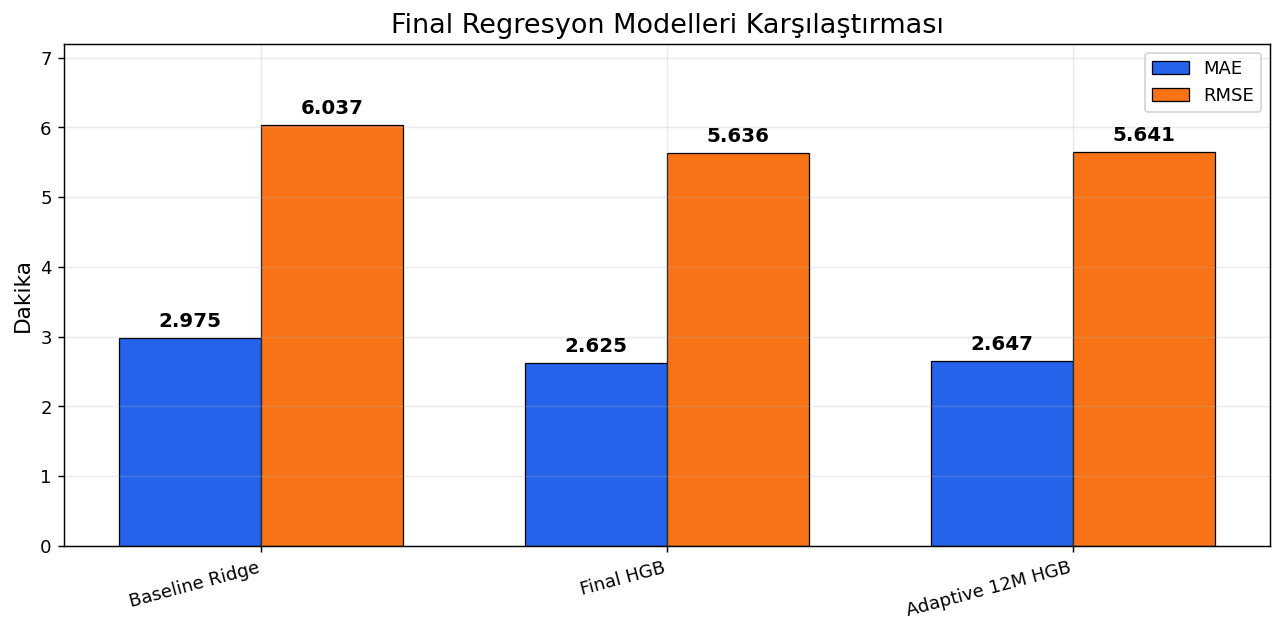

/tmp/ipykernel_1666/917955527.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(final_regression_results["model"], rotation=15, ha="right")


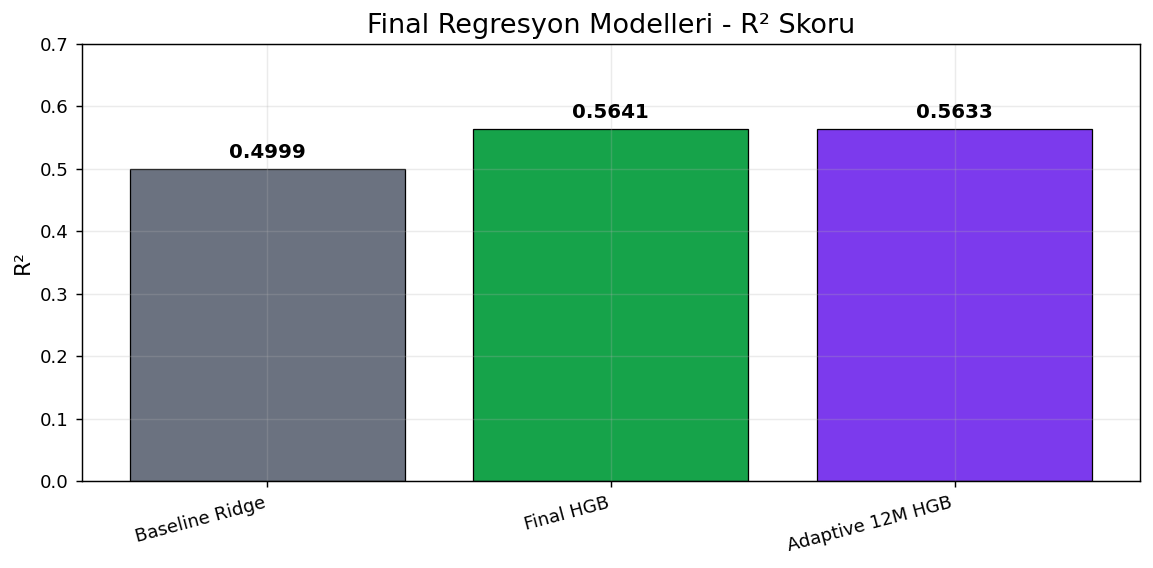

In [119]:
# #37 - Final regression model comparison

final_regression_results = pd.DataFrame([
    {
        "model": "Baseline Ridge",
        "RMSE_min": 6.037,
        "MAE_min": 2.975,
        "R2": 0.4999
    },
    {
        "model": "Final HGB",
        "RMSE_min": 5.636,
        "MAE_min": 2.625,
        "R2": 0.5641
    },
    {
        "model": "Adaptive 12M HGB",
        "RMSE_min": 5.641,
        "MAE_min": 2.647,
        "R2": 0.5633
    }
])

display(
    final_regression_results
    .style
    .format({"RMSE_min": "{:.3f}", "MAE_min": "{:.3f}", "R2": "{:.4f}"})
    .background_gradient(subset=["RMSE_min", "MAE_min"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
)

x = np.arange(len(final_regression_results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width / 2,
    final_regression_results["MAE_min"],
    width,
    label="MAE",
    color=COLORS["blue"],
    edgecolor="black",
    linewidth=0.7
)

bars2 = ax.bar(
    x + width / 2,
    final_regression_results["RMSE_min"],
    width,
    label="RMSE",
    color=COLORS["orange"],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Final Regresyon Modelleri Karşılaştırması")
ax.set_ylabel("Dakika")
ax.set_xticks(x)
ax.set_xticklabels(final_regression_results["model"], rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 7.2)

ax.bar_label(bars1, fmt="%.3f", padding=4, fontweight="bold")
ax.bar_label(bars2, fmt="%.3f", padding=4, fontweight="bold")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.bar(
    final_regression_results["model"],
    final_regression_results["R2"],
    color=[COLORS["gray"], COLORS["green"], COLORS["purple"]],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Final Regresyon Modelleri - R² Skoru")
ax.set_ylabel("R²")
ax.set_ylim(0, 0.70)
ax.set_xticklabels(final_regression_results["model"], rotation=15, ha="right")

ax.bar_label(bars, fmt="%.4f", padding=4, fontweight="bold")

plt.tight_layout()
plt.show()

,class,precision,recall,f1_score,support
0,Normal trip <=30,0.9823,0.9867,0.9845,27187
1,Long trip >30,0.5776,0.5056,0.5392,979


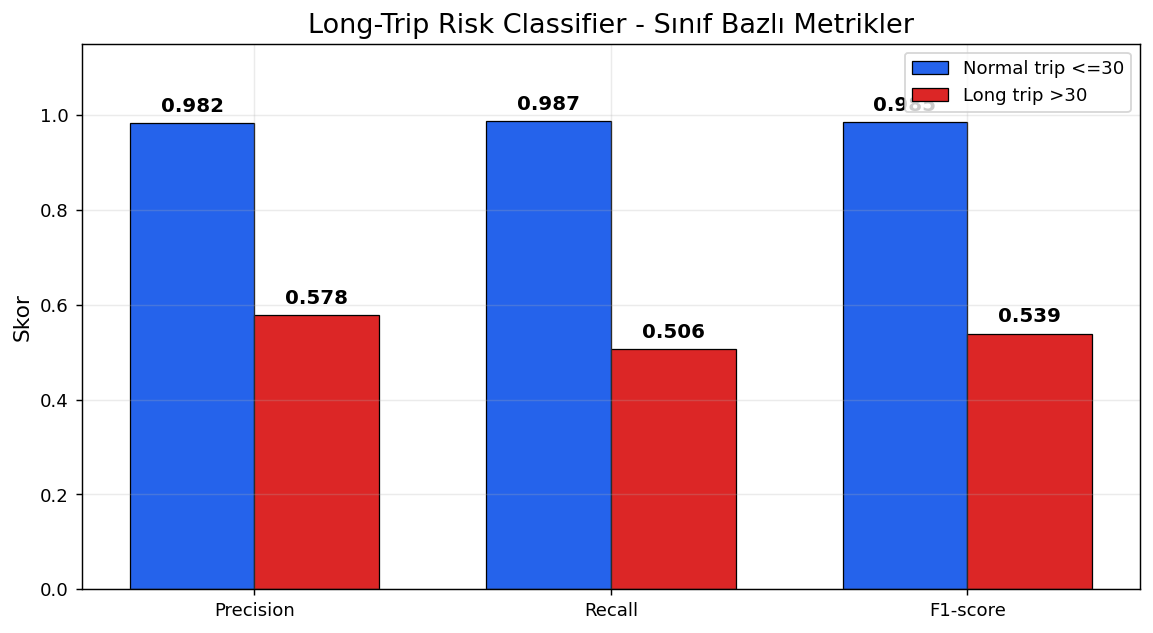

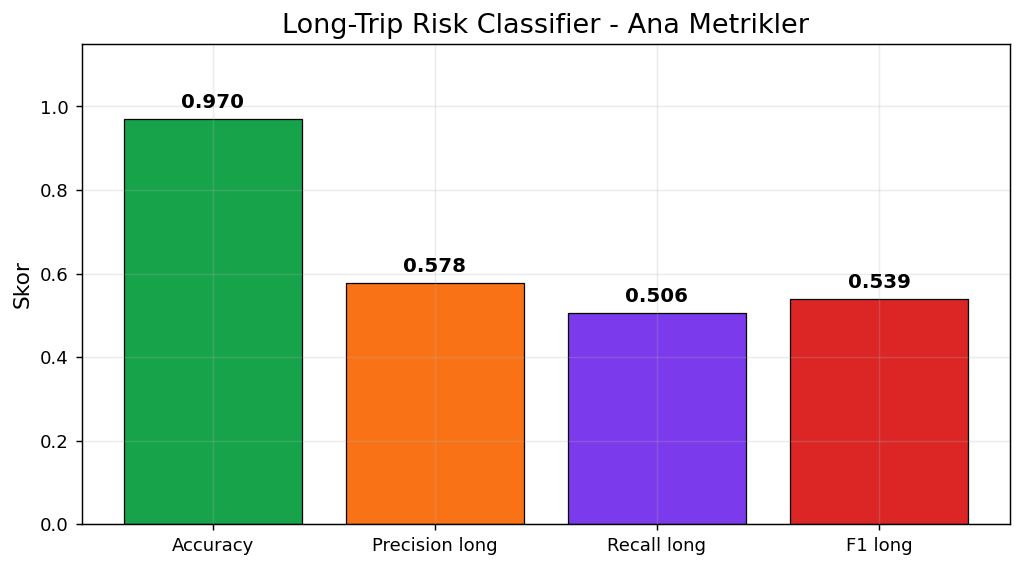

In [120]:
# #38 - Long-trip risk classifier metrics

risk_metric_summary = pd.DataFrame([
    {
        "class": "Normal trip <=30",
        "precision": 0.9823,
        "recall": 0.9867,
        "f1_score": 0.9845,
        "support": 27187
    },
    {
        "class": "Long trip >30",
        "precision": 0.5776,
        "recall": 0.5056,
        "f1_score": 0.5392,
        "support": 979
    }
])

display(
    risk_metric_summary
    .style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1_score": "{:.4f}",
        "support": "{:.0f}"
    })
    .background_gradient(subset=["precision", "recall", "f1_score"], cmap="RdYlGn")
)

metric_names = ["precision", "recall", "f1_score"]
x = np.arange(len(metric_names))
width = 0.35

normal_scores = risk_metric_summary.loc[0, metric_names].values.astype(float)
long_scores = risk_metric_summary.loc[1, metric_names].values.astype(float)

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width / 2,
    normal_scores,
    width,
    label="Normal trip <=30",
    color=COLORS["blue"],
    edgecolor="black",
    linewidth=0.7
)

bars2 = ax.bar(
    x + width / 2,
    long_scores,
    width,
    label="Long trip >30",
    color=COLORS["red"],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Long-Trip Risk Classifier - Sınıf Bazlı Metrikler")
ax.set_ylabel("Skor")
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1-score"])
ax.legend()

ax.bar_label(bars1, fmt="%.3f", padding=4, fontweight="bold")
ax.bar_label(bars2, fmt="%.3f", padding=4, fontweight="bold")

plt.tight_layout()
plt.show()

overall_risk_metrics = pd.DataFrame([
    {"metric": "Accuracy", "score": 0.9700},
    {"metric": "Precision long", "score": 0.5776},
    {"metric": "Recall long", "score": 0.5056},
    {"metric": "F1 long", "score": 0.5392}
])

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    overall_risk_metrics["metric"],
    overall_risk_metrics["score"],
    color=[COLORS["green"], COLORS["orange"], COLORS["purple"], COLORS["red"]],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Long-Trip Risk Classifier - Ana Metrikler")
ax.set_ylabel("Skor")
ax.set_ylim(0, 1.15)
ax.bar_label(bars, fmt="%.3f", padding=4, fontweight="bold")

plt.tight_layout()
plt.show()

,Pred Normal <=30,Pred Long >30
Actual Normal <=30,26825,362
Actual Long >30,484,495


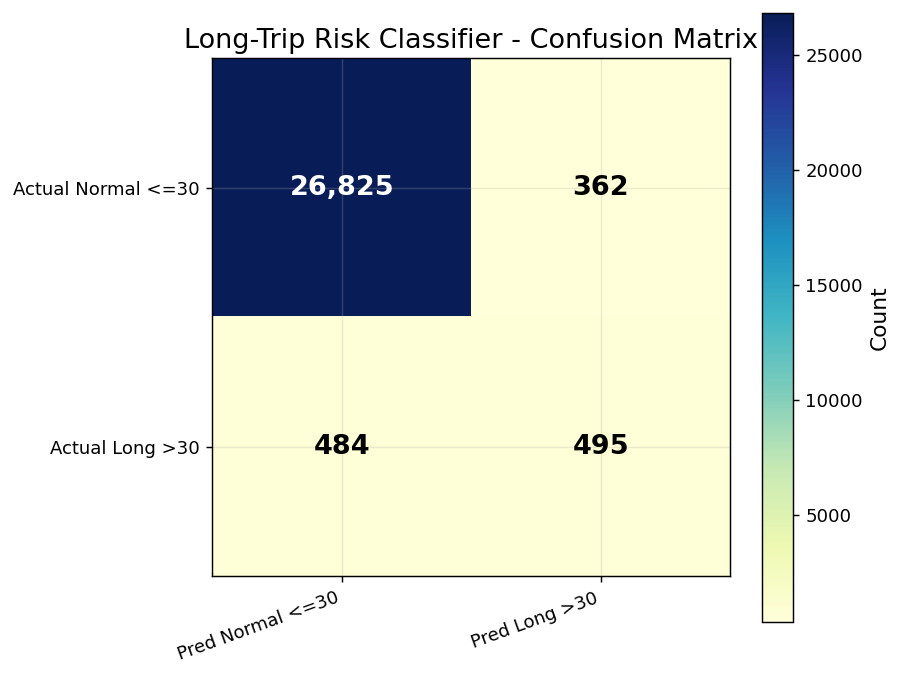

,Pred Normal <=30,Pred Long >30
Actual Normal <=30,0.987,0.013
Actual Long >30,0.494,0.506


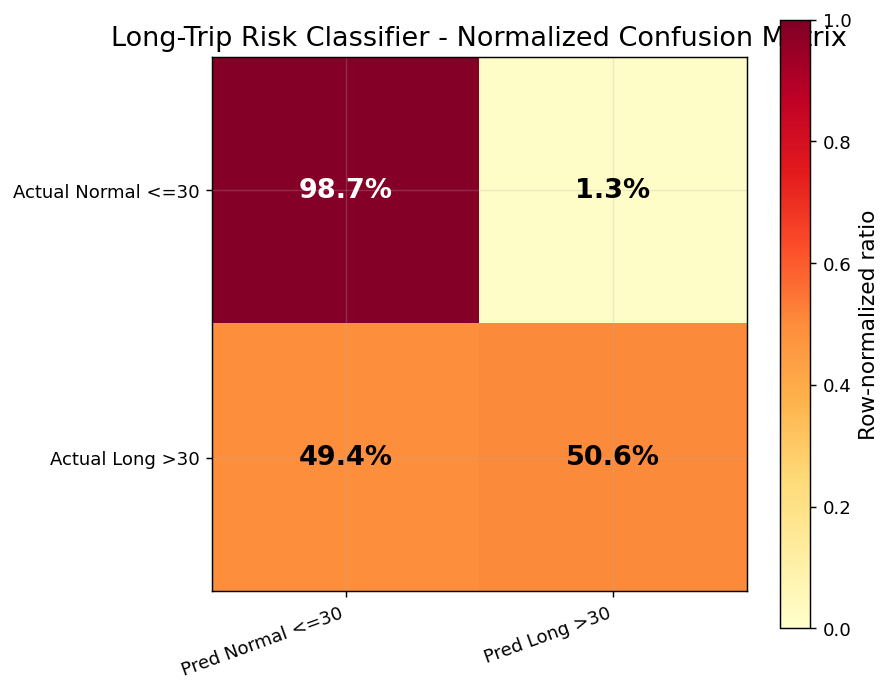

In [121]:
# #39 - Clear confusion matrix visualizations

risk_cm = np.array([
    [26825, 362],
    [484, 495]
])

risk_labels = ["Normal <=30", "Long >30"]

risk_cm_df = pd.DataFrame(
    risk_cm,
    index=[f"Actual {label}" for label in risk_labels],
    columns=[f"Pred {label}" for label in risk_labels]
)

display(risk_cm_df)

fig, ax = plt.subplots(figsize=(7, 5.8))

im = ax.imshow(risk_cm, cmap="YlGnBu")

ax.set_title("Long-Trip Risk Classifier - Confusion Matrix")
ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))
ax.set_xticklabels([f"Pred {label}" for label in risk_labels], rotation=20, ha="right")
ax.set_yticklabels([f"Actual {label}" for label in risk_labels])

for i in range(risk_cm.shape[0]):
    for j in range(risk_cm.shape[1]):
        value = risk_cm[i, j]
        text_color = "white" if value > risk_cm.max() * 0.45 else "black"
        ax.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=15,
            fontweight="bold"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Count")

plt.tight_layout()
plt.show()

risk_cm_norm = risk_cm / risk_cm.sum(axis=1, keepdims=True)

risk_cm_norm_df = pd.DataFrame(
    risk_cm_norm,
    index=[f"Actual {label}" for label in risk_labels],
    columns=[f"Pred {label}" for label in risk_labels]
)

display(risk_cm_norm_df.round(3))

fig, ax = plt.subplots(figsize=(7, 5.8))

im = ax.imshow(risk_cm_norm, cmap="YlOrRd", vmin=0, vmax=1)

ax.set_title("Long-Trip Risk Classifier - Normalized Confusion Matrix")
ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))
ax.set_xticklabels([f"Pred {label}" for label in risk_labels], rotation=20, ha="right")
ax.set_yticklabels([f"Actual {label}" for label in risk_labels])

for i in range(risk_cm_norm.shape[0]):
    for j in range(risk_cm_norm.shape[1]):
        value = risk_cm_norm[i, j]
        text_color = "white" if value > 0.55 else "black"
        ax.text(
            j,
            i,
            f"{value:.1%}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=15,
            fontweight="bold"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Row-normalized ratio")

plt.tight_layout()
plt.show()

,duration_bucket,n,actual_mean,predicted_mean,MAE_min,RMSE_min,mean_error,under_5_plus_rate,under_10_plus_rate
0,0-15 min,21964,7.523,8.364,1.688,2.214,-0.842,1.1%,0.0%
1,15-30 min,5223,20.296,18.197,4.116,5.790,2.098,22.2%,8.8%
2,30-60 min,942,36.528,23.601,13.034,16.976,12.927,72.0%,47.9%
3,60+ min,37,98.419,15.230,83.189,95.934,83.189,100.0%,100.0%


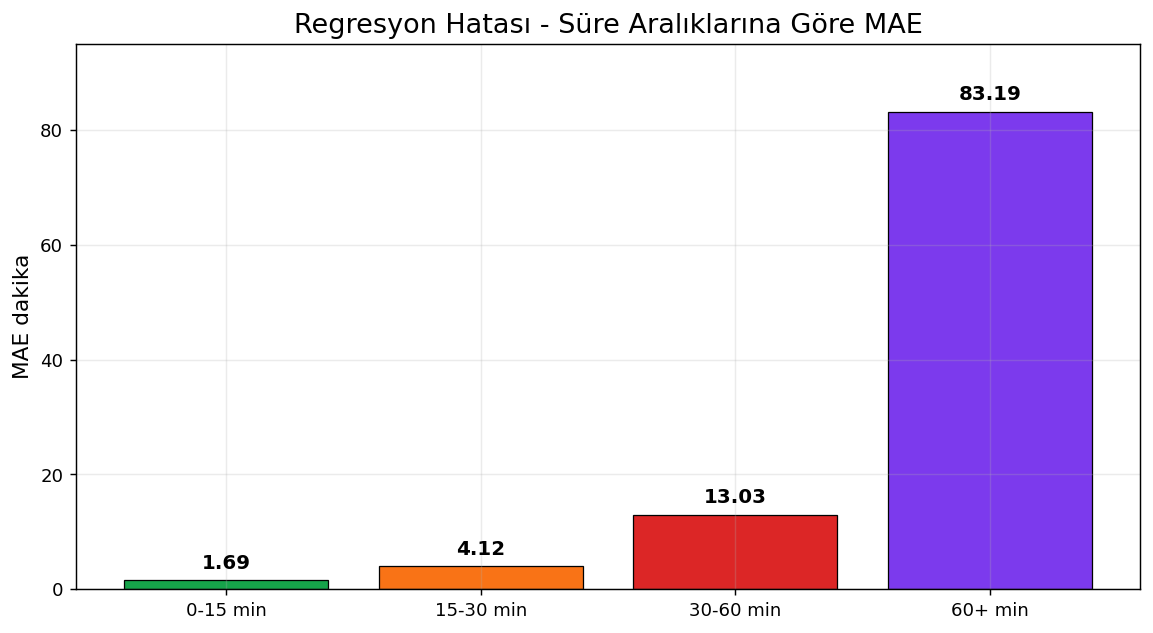

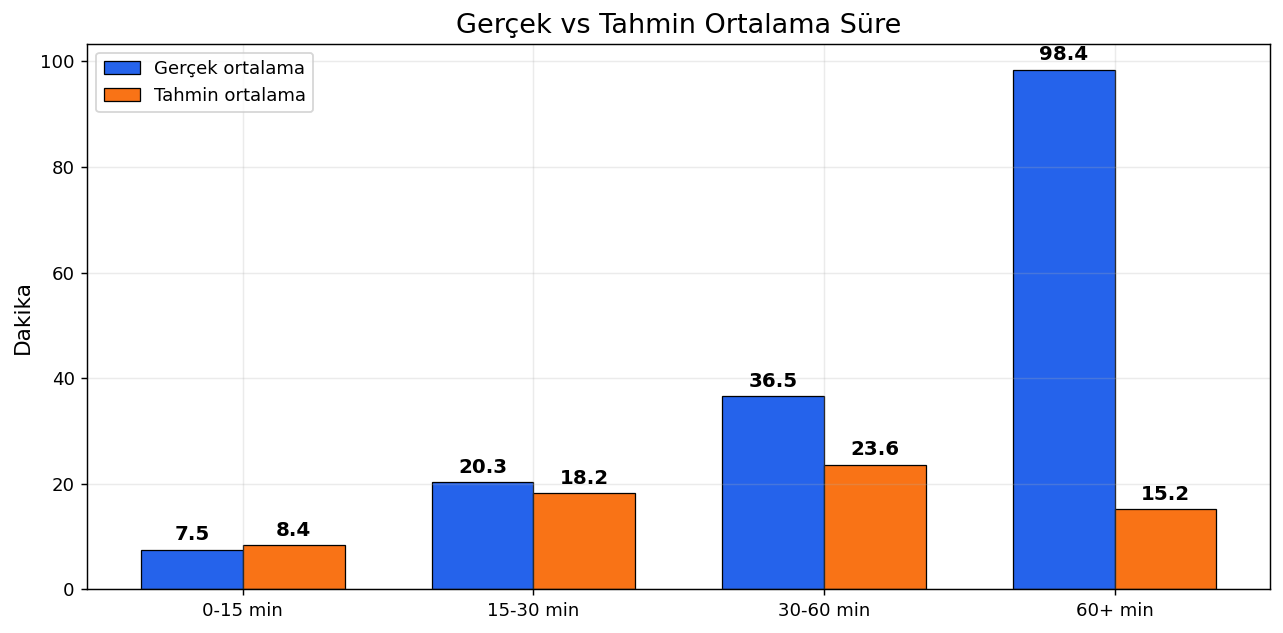

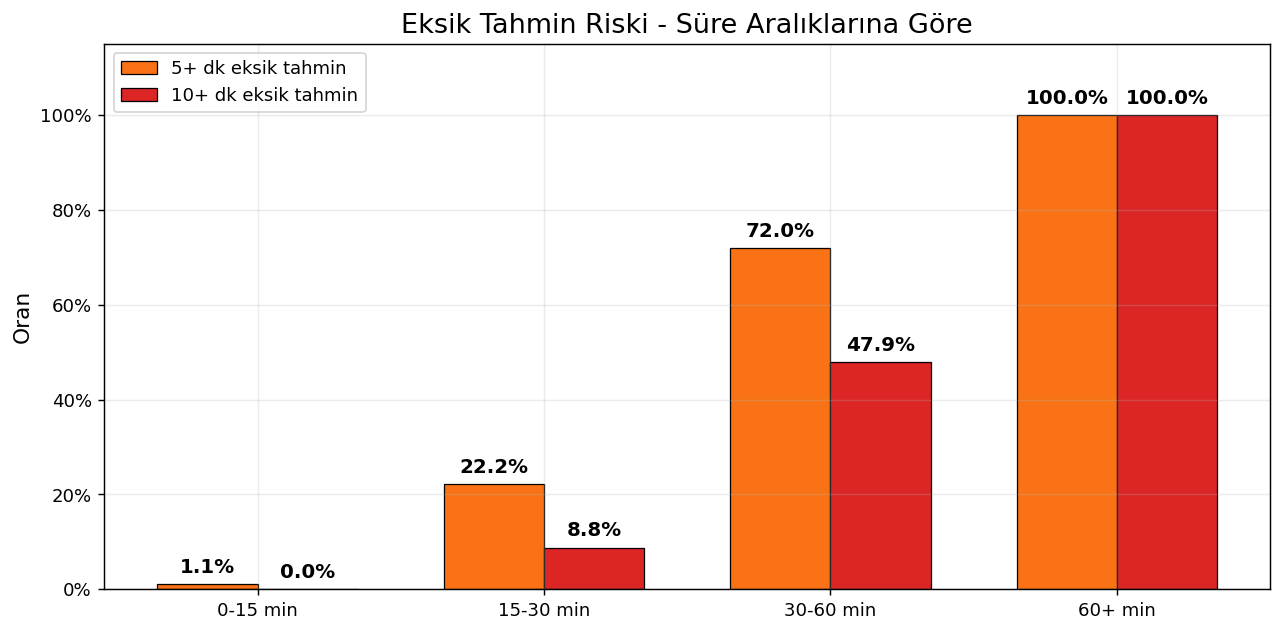

In [122]:
# #40 - Bucket-level error visualization

bucket_final_summary = pd.DataFrame([
    {
        "duration_bucket": "0-15 min",
        "n": 21964,
        "actual_mean": 7.523,
        "predicted_mean": 8.364,
        "MAE_min": 1.688,
        "RMSE_min": 2.214,
        "mean_error": -0.842,
        "under_5_plus_rate": 0.011,
        "under_10_plus_rate": 0.000
    },
    {
        "duration_bucket": "15-30 min",
        "n": 5223,
        "actual_mean": 20.296,
        "predicted_mean": 18.197,
        "MAE_min": 4.116,
        "RMSE_min": 5.790,
        "mean_error": 2.098,
        "under_5_plus_rate": 0.222,
        "under_10_plus_rate": 0.088
    },
    {
        "duration_bucket": "30-60 min",
        "n": 942,
        "actual_mean": 36.528,
        "predicted_mean": 23.601,
        "MAE_min": 13.034,
        "RMSE_min": 16.976,
        "mean_error": 12.927,
        "under_5_plus_rate": 0.720,
        "under_10_plus_rate": 0.479
    },
    {
        "duration_bucket": "60+ min",
        "n": 37,
        "actual_mean": 98.419,
        "predicted_mean": 15.230,
        "MAE_min": 83.189,
        "RMSE_min": 95.934,
        "mean_error": 83.189,
        "under_5_plus_rate": 1.000,
        "under_10_plus_rate": 1.000
    }
])

display(
    bucket_final_summary
    .style
    .format({
        "n": "{:.0f}",
        "actual_mean": "{:.3f}",
        "predicted_mean": "{:.3f}",
        "MAE_min": "{:.3f}",
        "RMSE_min": "{:.3f}",
        "mean_error": "{:.3f}",
        "under_5_plus_rate": "{:.1%}",
        "under_10_plus_rate": "{:.1%}"
    })
    .background_gradient(subset=["MAE_min", "RMSE_min", "under_5_plus_rate", "under_10_plus_rate"], cmap="YlOrRd")
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    bucket_final_summary["duration_bucket"],
    bucket_final_summary["MAE_min"],
    color=[COLORS["green"], COLORS["orange"], COLORS["red"], COLORS["purple"]],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Regresyon Hatası - Süre Aralıklarına Göre MAE")
ax.set_ylabel("MAE dakika")
ax.set_ylim(0, 95)
ax.bar_label(bars, fmt="%.2f", padding=4, fontweight="bold")

plt.tight_layout()
plt.show()

x = np.arange(len(bucket_final_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width / 2,
    bucket_final_summary["actual_mean"],
    width,
    label="Gerçek ortalama",
    color=COLORS["blue"],
    edgecolor="black",
    linewidth=0.7
)

bars2 = ax.bar(
    x + width / 2,
    bucket_final_summary["predicted_mean"],
    width,
    label="Tahmin ortalama",
    color=COLORS["orange"],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Gerçek vs Tahmin Ortalama Süre")
ax.set_ylabel("Dakika")
ax.set_xticks(x)
ax.set_xticklabels(bucket_final_summary["duration_bucket"])
ax.legend()

ax.bar_label(bars1, fmt="%.1f", padding=3, fontweight="bold")
ax.bar_label(bars2, fmt="%.1f", padding=3, fontweight="bold")

plt.tight_layout()
plt.show()

risk_rate_plot = bucket_final_summary[
    ["duration_bucket", "under_5_plus_rate", "under_10_plus_rate"]
].copy()

x = np.arange(len(risk_rate_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width / 2,
    risk_rate_plot["under_5_plus_rate"],
    width,
    label="5+ dk eksik tahmin",
    color=COLORS["orange"],
    edgecolor="black",
    linewidth=0.7
)

bars2 = ax.bar(
    x + width / 2,
    risk_rate_plot["under_10_plus_rate"],
    width,
    label="10+ dk eksik tahmin",
    color=COLORS["red"],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Eksik Tahmin Riski - Süre Aralıklarına Göre")
ax.set_ylabel("Oran")
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(risk_rate_plot["duration_bucket"])
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()

ax.bar_label(bars1, labels=[f"{v:.1%}" for v in risk_rate_plot["under_5_plus_rate"]], padding=4, fontweight="bold")
ax.bar_label(bars2, labels=[f"{v:.1%}" for v in risk_rate_plot["under_10_plus_rate"]], padding=4, fontweight="bold")

plt.tight_layout()
plt.show()

,lookback_months,RMSE_min,MAE_min,R2,train_n
0,3,6.472,3.125,0.5327,"27,817"
1,6,6.490,3.098,0.5302,"49,916"
2,9,6.495,3.075,0.5293,"62,800"
3,12,6.510,3.068,0.5272,"81,567"


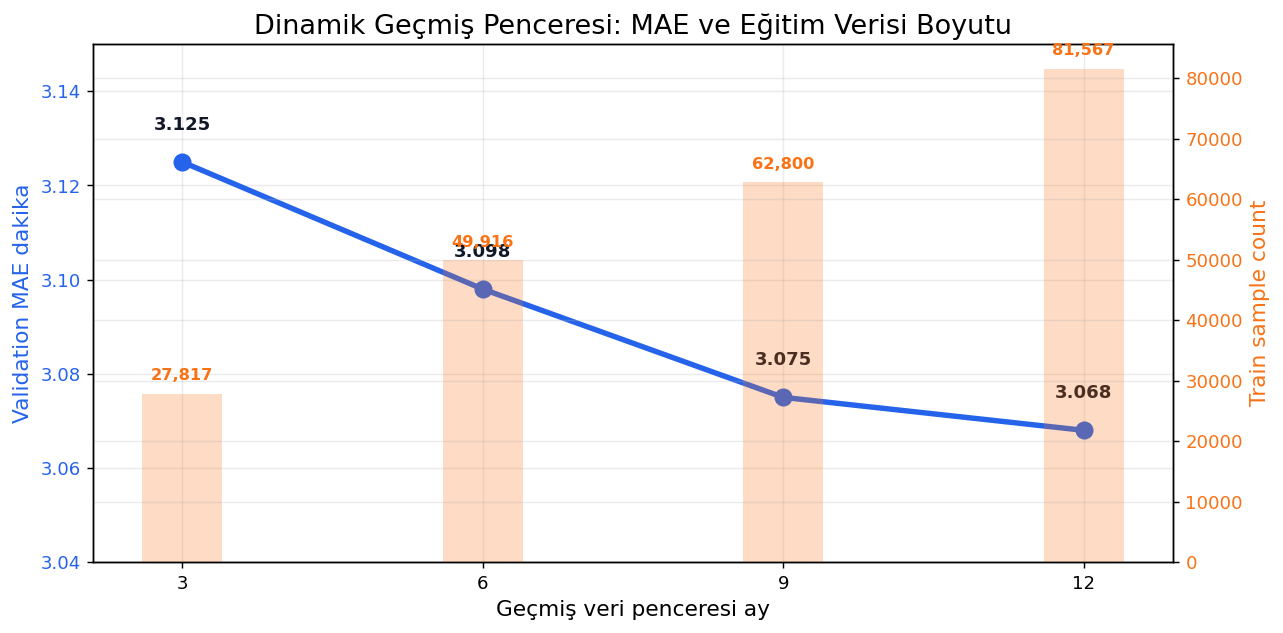

In [123]:
# #41 - Adaptive lookback window visualization

lookback_final_summary = pd.DataFrame([
    {
        "lookback_months": 3,
        "RMSE_min": 6.472,
        "MAE_min": 3.125,
        "R2": 0.5327,
        "train_n": 27817
    },
    {
        "lookback_months": 6,
        "RMSE_min": 6.490,
        "MAE_min": 3.098,
        "R2": 0.5302,
        "train_n": 49916
    },
    {
        "lookback_months": 9,
        "RMSE_min": 6.495,
        "MAE_min": 3.075,
        "R2": 0.5293,
        "train_n": 62800
    },
    {
        "lookback_months": 12,
        "RMSE_min": 6.510,
        "MAE_min": 3.068,
        "R2": 0.5272,
        "train_n": 81567
    }
])

display(
    lookback_final_summary
    .style
    .format({
        "RMSE_min": "{:.3f}",
        "MAE_min": "{:.3f}",
        "R2": "{:.4f}",
        "train_n": "{:,.0f}"
    })
    .background_gradient(subset=["MAE_min"], cmap="RdYlGn_r")
    .background_gradient(subset=["train_n"], cmap="Blues")
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    lookback_final_summary["lookback_months"],
    lookback_final_summary["MAE_min"],
    marker="o",
    markersize=9,
    linewidth=3,
    color=COLORS["blue"],
    label="Validation MAE"
)

for _, row in lookback_final_summary.iterrows():
    ax1.text(
        row["lookback_months"],
        row["MAE_min"] + 0.006,
        f'{row["MAE_min"]:.3f}',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=COLORS["dark"]
    )

ax1.set_xlabel("Geçmiş veri penceresi ay")
ax1.set_ylabel("Validation MAE dakika", color=COLORS["blue"])
ax1.tick_params(axis="y", labelcolor=COLORS["blue"])
ax1.set_xticks(lookback_final_summary["lookback_months"])
ax1.set_ylim(3.04, 3.15)

ax2 = ax1.twinx()

bars = ax2.bar(
    lookback_final_summary["lookback_months"],
    lookback_final_summary["train_n"],
    alpha=0.25,
    color=COLORS["orange"],
    label="Train sample"
)

ax2.set_ylabel("Train sample count", color=COLORS["orange"])
ax2.tick_params(axis="y", labelcolor=COLORS["orange"])

for bar, value in zip(bars, lookback_final_summary["train_n"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1800,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=COLORS["orange"]
    )

ax1.set_title("Dinamik Geçmiş Penceresi: MAE ve Eğitim Verisi Boyutu")

fig.tight_layout()
plt.show()

## Problem 2 - Gaussian Naive Bayes ve Gender Prediction

Bu bölümde notebookun ikinci görevi olan **bike speed ile gender prediction** kısmını tamamladım.

Burada iki şeyi ayırmak önemli:

1. **Ödevin istediği temel fikir:**  
   Speed değişkeni sürekli bir değişken olduğu için `P(speed | gender)` dağılımını Gaussian Naive Bayes mantığıyla modellemek.

2. **Mühendis gibi ekstra kontrol:**  
   Sadece accuracy yüksek çıksın diye modeli çoğunluk sınıfına yatırmak kolay. Ama bu kaliteli bir çözüm değil. Bu yüzden accuracy yanında balanced accuracy, macro F1, sınıf bazlı precision/recall ve confusion matrix de incelendi.

`gender = 0` bilinmeyen kategori olduğu için dışarıda bırakıldı. Model yalnızca `gender = 1` ve `gender = 2` kayıtları üzerinde kuruldu.

Bu bölümde önce saf GaussianNB baseline kuruldu. Sonra threshold tuning ve daha güçlü benchmark modellerle, bu problemin gerçekten ne kadar iyileştirilebileceği test edildi.


In [124]:
# #42 - Problem 2 data preparation: gender prediction için kontrollü örnekleme

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.utils.class_weight import compute_sample_weight

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# trips_speed_gender_clean daha önce oluşmadıysa burada güvenli şekilde oluşturuyorum.
# gender = 0 bilinmeyen kategori olduğu için bu problemde yok.
try:
    con.sql("SELECT * FROM trips_speed_gender_clean LIMIT 1;").df()
    print("trips_speed_gender_clean view zaten hazır.")
except Exception:
    print("trips_speed_gender_clean view yoktu, şimdi oluşturuyorum...")

    con.sql("""
    CREATE OR REPLACE VIEW trips_speed_gender_clean AS
    SELECT *
    FROM trips_features
    WHERE gender IN (1, 2)
      AND duration_min BETWEEN 1 AND 180
      AND distance_km BETWEEN 0.10 AND 35
      AND speed_kmh BETWEEN 1 AND 45
      AND birth_year IS NOT NULL
      AND age_at_trip BETWEEN 14 AND 90
      AND usertype IS NOT NULL;
    """)

# Hash tabanlı örnekleme kullanıyorum.
# Böylece aynı hücre tekrar çalışsa bile aynı örnekler gelir.
gender_sample_key = """
CAST(bikeid AS VARCHAR) || '_' ||
CAST(start_at AS VARCHAR) || '_' ||
CAST(start_station_id AS VARCHAR) || '_' ||
CAST(end_station_id AS VARCHAR)
"""

gender_base_select = """
    gender,
    CASE WHEN gender = 2 THEN 1 ELSE 0 END AS gender_binary,

    speed_kmh,
    ln(speed_kmh) AS log_speed,

    duration_min,
    distance_km,
    ln(distance_km + 0.05) AS log_distance,

    start_hour,
    start_month,
    day_of_week,
    is_weekend,
    is_roundtrip,

    age_at_trip,

    CASE WHEN usertype = 'Subscriber' THEN 1 ELSE 0 END AS is_subscriber,
    CASE WHEN usertype = 'Customer' THEN 1 ELSE 0 END AS is_customer,

    start_station_id,
    end_station_id,
    CAST(start_station_id AS VARCHAR) || '->' || CAST(end_station_id AS VARCHAR) AS station_pair,

    start_lat,
    start_lon,
    end_lat,
    end_lon,

    start_at
"""

# Server şişmesin diye train/test örneklerini küçük ama yeterli tuttum.
# Not: Daha büyük sample accuracy'yi biraz oynatabilir ama connection koparma riskini artırıyor.
con.sql(f"""
CREATE OR REPLACE TEMP TABLE gender_train_raw AS
SELECT {gender_base_select}
FROM trips_speed_gender_clean
WHERE start_at < TIMESTAMP '2016-10-01'
  AND hash({gender_sample_key}) % 1000000 < 7000;
""")

con.sql(f"""
CREATE OR REPLACE TEMP TABLE gender_valid_raw AS
SELECT {gender_base_select}
FROM trips_speed_gender_clean
WHERE start_at >= TIMESTAMP '2016-10-01'
  AND start_at < TIMESTAMP '2016-12-01'
  AND hash({gender_sample_key}) % 1000000 < 15000;
""")

con.sql(f"""
CREATE OR REPLACE TEMP TABLE gender_test_raw AS
SELECT {gender_base_select}
FROM trips_speed_gender_clean
WHERE start_at >= TIMESTAMP '2016-12-01'
  AND start_at < TIMESTAMP '2017-01-01'
  AND hash({gender_sample_key}) % 1000000 < 35000;
""")

gender_split_check = con.sql("""
SELECT
    'train' AS split,
    COUNT(*) AS n,
    SUM(CASE WHEN gender = 1 THEN 1 ELSE 0 END) AS gender_1_n,
    SUM(CASE WHEN gender = 2 THEN 1 ELSE 0 END) AS gender_2_n,
    ROUND(AVG(gender_binary), 4) AS gender_2_rate,
    MIN(start_at) AS min_date,
    MAX(start_at) AS max_date
FROM gender_train_raw

UNION ALL

SELECT
    'valid' AS split,
    COUNT(*) AS n,
    SUM(CASE WHEN gender = 1 THEN 1 ELSE 0 END) AS gender_1_n,
    SUM(CASE WHEN gender = 2 THEN 1 ELSE 0 END) AS gender_2_n,
    ROUND(AVG(gender_binary), 4) AS gender_2_rate,
    MIN(start_at) AS min_date,
    MAX(start_at) AS max_date
FROM gender_valid_raw

UNION ALL

SELECT
    'test' AS split,
    COUNT(*) AS n,
    SUM(CASE WHEN gender = 1 THEN 1 ELSE 0 END) AS gender_1_n,
    SUM(CASE WHEN gender = 2 THEN 1 ELSE 0 END) AS gender_2_n,
    ROUND(AVG(gender_binary), 4) AS gender_2_rate,
    MIN(start_at) AS min_date,
    MAX(start_at) AS max_date
FROM gender_test_raw;
""").df()

display(gender_split_check)


trips_speed_gender_clean view zaten hazır.


,split,n,gender_1_n,gender_2_n,gender_2_rate,min_date,max_date
0,train,120697,91976.0,28721.0,0.2380,2015-01-01 00:55:00,2016-09-30 23:21:01
1,valid,36597,27406.0,9191.0,0.2511,2016-10-01 00:04:11,2016-11-30 23:43:04
2,test,26301,20314.0,5987.0,0.2276,2016-12-01 00:02:10,2016-12-31 23:53:28


In [126]:
# #43 - Train-only target encoding for gender problem
# Bu hücre memory-safe versiyon.
# Pair-level TE'yi bilerek çıkardım çünkü hem ağır hem de server'ı şişirme riski var.
# Start/end station TE yeterince sinyal verir ve daha stabil çalışır.

import gc
import numpy as np
import pandas as pd

gender_global_rate = con.sql("""
SELECT AVG(CAST(gender_binary AS DOUBLE))
FROM gender_train_raw;
""").fetchone()[0]

gender_global_rate = float(gender_global_rate)

print("Train global gender_2 rate:", round(gender_global_rate, 4))

# Start station gender_2 oranı
con.sql(f"""
CREATE OR REPLACE TEMP TABLE gender_start_stats AS
SELECT
    start_station_id,
    COUNT(*) AS start_n,
    (
        SUM(CAST(gender_binary AS DOUBLE)) + 30.0 * CAST({gender_global_rate} AS DOUBLE)
    ) / (
        COUNT(*) + 30.0
    ) AS start_gender2_te
FROM gender_train_raw
GROUP BY start_station_id;
""")

# End station gender_2 oranı
con.sql(f"""
CREATE OR REPLACE TEMP TABLE gender_end_stats AS
SELECT
    end_station_id,
    COUNT(*) AS end_n,
    (
        SUM(CAST(gender_binary AS DOUBLE)) + 30.0 * CAST({gender_global_rate} AS DOUBLE)
    ) / (
        COUNT(*) + 30.0
    ) AS end_gender2_te
FROM gender_train_raw
GROUP BY end_station_id;
""")


def build_gender_model_frame(table_name):
    query = f"""
    SELECT
        t.gender,
        t.gender_binary,

        t.speed_kmh,
        t.log_speed,

        t.duration_min,
        t.distance_km,
        t.log_distance,

        t.start_hour,
        sin(2 * pi() * t.start_hour / 24.0) AS hour_sin,
        cos(2 * pi() * t.start_hour / 24.0) AS hour_cos,

        t.start_month,
        sin(2 * pi() * t.start_month / 12.0) AS month_sin,
        cos(2 * pi() * t.start_month / 12.0) AS month_cos,

        t.day_of_week,
        sin(2 * pi() * t.day_of_week / 7.0) AS dow_sin,
        cos(2 * pi() * t.day_of_week / 7.0) AS dow_cos,

        t.is_weekend,
        t.is_roundtrip,
        t.age_at_trip,

        t.is_subscriber,
        t.is_customer,

        t.start_lat,
        t.start_lon,
        t.end_lat,
        t.end_lon,

        COALESCE(ss.start_gender2_te, CAST({gender_global_rate} AS DOUBLE)) AS start_gender2_te,
        COALESCE(es.end_gender2_te, CAST({gender_global_rate} AS DOUBLE)) AS end_gender2_te,

        ln(1 + COALESCE(ss.start_n, 0)) AS log_start_n,
        ln(1 + COALESCE(es.end_n, 0)) AS log_end_n

    FROM {table_name} t

    LEFT JOIN gender_start_stats ss
        ON t.start_station_id = ss.start_station_id

    LEFT JOIN gender_end_stats es
        ON t.end_station_id = es.end_station_id;
    """

    df = con.sql(query).df()

    # RAM dostu olsun diye sayıları küçültüyoruz
    for col in df.columns:
        if col not in ["gender", "gender_binary"]:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

    df["gender"] = df["gender"].astype("int8")
    df["gender_binary"] = df["gender_binary"].astype("int8")

    return df


gender_train_df = build_gender_model_frame("gender_train_raw")
gender_valid_df = build_gender_model_frame("gender_valid_raw")
gender_test_df = build_gender_model_frame("gender_test_raw")

print("Train shape:", gender_train_df.shape)
print("Valid shape:", gender_valid_df.shape)
print("Test shape :", gender_test_df.shape)

display(gender_train_df.head())

gc.collect()

Train global gender_2 rate: 0.238
Train shape: (120697, 29)
Valid shape: (36597, 29)
Test shape : (26301, 29)


,gender,gender_binary,speed_kmh,log_speed,duration_min,distance_km,log_distance,start_hour,hour_sin,hour_cos,start_month,month_sin,month_cos,day_of_week,dow_sin,dow_cos,is_weekend,is_roundtrip,age_at_trip,is_subscriber,is_customer,start_lat,start_lon,end_lat,end_lon,start_gender2_te,end_gender2_te,log_start_n,log_end_n
0,1,0,9.236681,2.223183,9.0,1.385502,0.361515,0.0,0.000000,1.000000,1.0,0.5,0.866025,4.0,-0.433884,-0.900969,0.0,0.0,51.0,1.0,0.0,40.718941,-73.992661,40.717823,-73.976288,0.293520,0.294569,6.059123,4.997212
1,2,1,7.120951,1.963041,18.0,2.136285,0.782204,2.0,0.500000,0.866025,1.0,0.5,0.866025,4.0,-0.433884,-0.900969,0.0,0.0,25.0,1.0,0.0,40.739017,-74.002640,40.729553,-73.980576,0.252246,0.240952,6.699501,6.115892
2,1,0,17.217108,2.845904,22.0,6.312940,1.850490,3.0,0.707107,0.707107,1.0,0.5,0.866025,4.0,-0.433884,-0.900969,0.0,0.0,33.0,1.0,0.0,40.769154,-73.981918,40.716251,-74.009109,0.237502,0.254645,6.291569,5.598422
3,2,1,12.683893,2.540333,26.0,5.496354,1.713141,9.0,0.707107,-0.707107,1.0,0.5,0.866025,4.0,-0.433884,-0.900969,0.0,0.0,37.0,1.0,0.0,40.707874,-74.001671,40.755272,-73.983170,0.221540,0.174490,5.545177,5.659482
4,1,0,9.187703,2.217866,4.0,0.612514,-0.411714,10.0,0.500000,-0.866025,1.0,0.5,0.866025,4.0,-0.433884,-0.900969,0.0,0.0,25.0,1.0,0.0,40.727409,-73.981422,40.722176,-73.983688,0.306631,0.242397,6.336826,6.100319


26927

speed_kmh                      log_speed                      distance_km                      duration_min                        age_at_trip                       
           count   mean median    std     count   mean median    std       count   mean median    std        count    mean  median    std       count    mean median     std
gender                                                                                                                                                                      
1          91976  9.526  9.488  2.781     91976  2.202  2.250  0.351       91976  1.759  1.382  1.282        91976  11.579   9.225  8.360       91976  38.743   36.0  11.542
2          28721  8.538  8.493  2.506     28721  2.093  2.139  0.348       28721  1.856  1.477  1.305        28721  13.597  11.000  9.504       28721  36.952   34.0  11.262

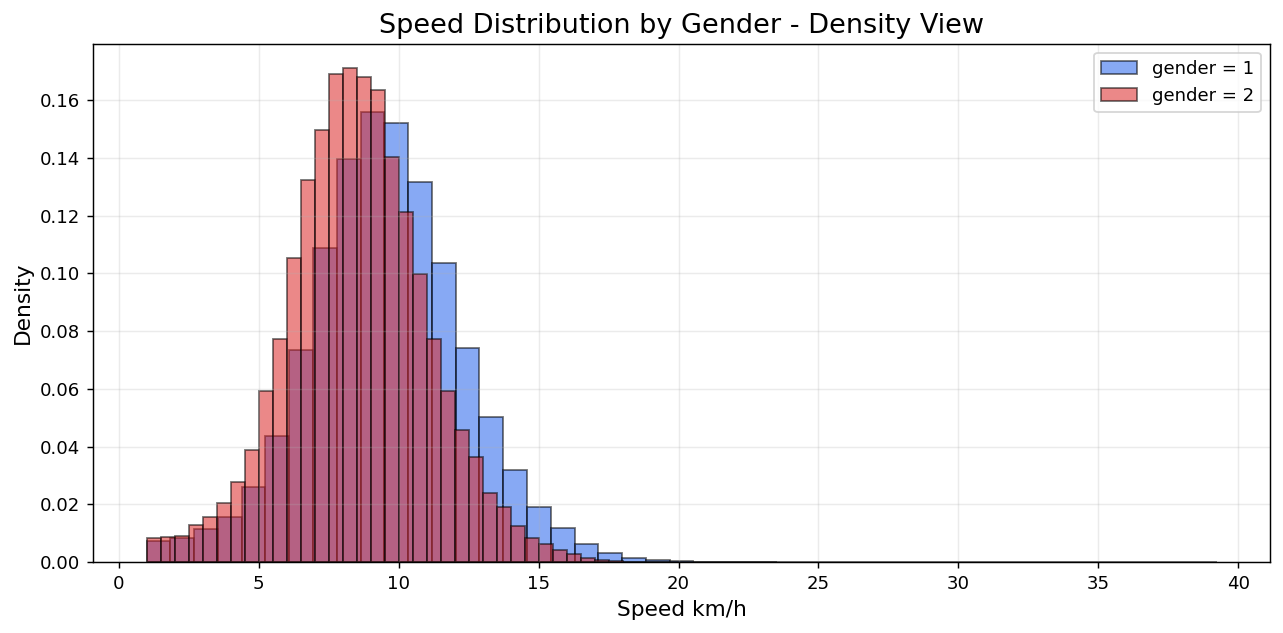

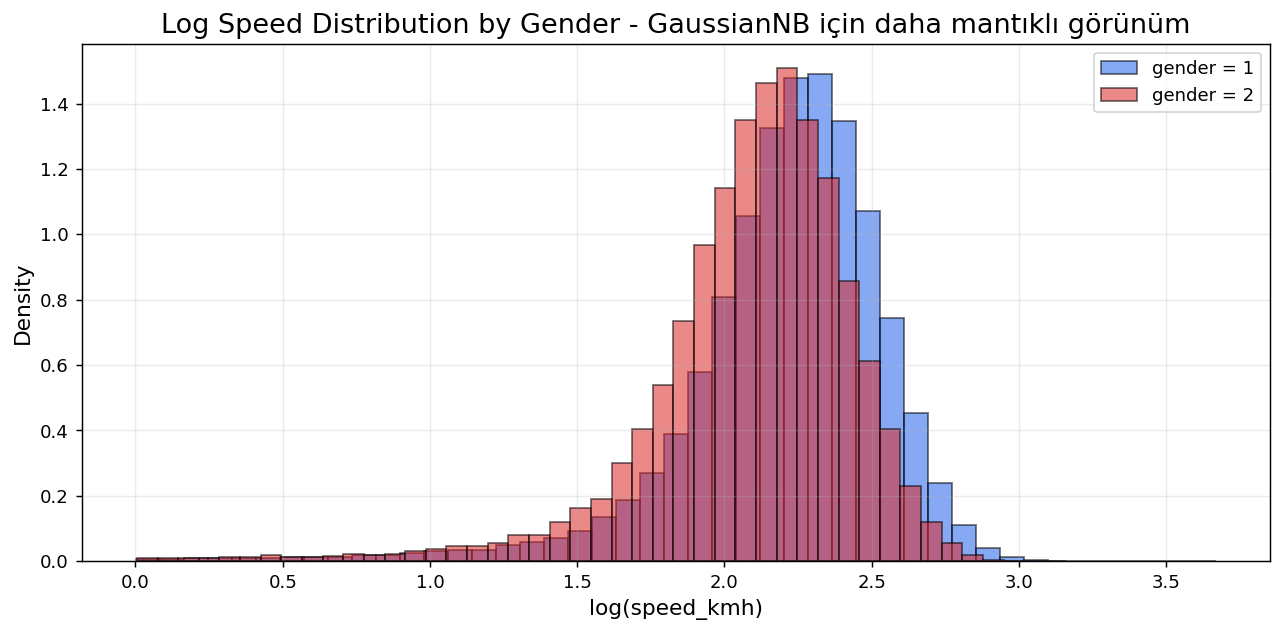

In [127]:
# #44 - Speed distribution check
# NB tarafında önce dağılıma bakıyorum: speed gerçekten sınıfları ayırıyor mu?

speed_summary_by_gender = (
    gender_train_df
    .groupby("gender")[["speed_kmh", "log_speed", "distance_km", "duration_min", "age_at_trip"]]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(speed_summary_by_gender)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    gender_train_df.loc[gender_train_df["gender"] == 1, "speed_kmh"],
    bins=45,
    density=True,
    alpha=0.55,
    label="gender = 1",
    color="#2563EB",
    edgecolor="black"
)

ax.hist(
    gender_train_df.loc[gender_train_df["gender"] == 2, "speed_kmh"],
    bins=45,
    density=True,
    alpha=0.55,
    label="gender = 2",
    color="#DC2626",
    edgecolor="black"
)

ax.set_title("Speed Distribution by Gender - Density View")
ax.set_xlabel("Speed km/h")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    gender_train_df.loc[gender_train_df["gender"] == 1, "log_speed"],
    bins=45,
    density=True,
    alpha=0.55,
    label="gender = 1",
    color="#2563EB",
    edgecolor="black"
)

ax.hist(
    gender_train_df.loc[gender_train_df["gender"] == 2, "log_speed"],
    bins=45,
    density=True,
    alpha=0.55,
    label="gender = 2",
    color="#DC2626",
    edgecolor="black"
)

ax.set_title("Log Speed Distribution by Gender - GaussianNB için daha mantıklı görünüm")
ax.set_xlabel("log(speed_kmh)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [129]:
# #45 - Required Gaussian Naive Bayes baselines
# Burada ödevin istediği ana GaussianNB fikrini test ediyorum.
# Pair-level TE'yi bilerek kullanmıyorum çünkü hem RAM'i şişiriyor hem de overfit riski yüksek.
# Onun yerine start/end station priors kullanıyorum. Daha temiz, daha stabil.

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import numpy as np
import pandas as pd

nb_experiments = [
    {
        "model_name": "GaussianNB - raw speed",
        "features": ["speed_kmh"],
        "model": GaussianNB()
    },
    {
        "model_name": "GaussianNB - log speed",
        "features": ["log_speed"],
        "model": GaussianNB()
    },
    {
        "model_name": "GaussianNB - log speed equal priors",
        "features": ["log_speed"],
        "model": GaussianNB(priors=[0.5, 0.5])
    },
    {
        "model_name": "GaussianNB - log speed + station priors",
        "features": [
            "log_speed",
            "start_gender2_te",
            "end_gender2_te",
            "log_start_n",
            "log_end_n"
        ],
        "model": GaussianNB(priors=[0.5, 0.5])
    }
]


def get_positive_class_probability(model, X):
    # Positive class = gender_binary 1 = gender_2
    class_index = list(model.classes_).index(1)
    return model.predict_proba(X)[:, class_index]


def evaluate_binary_model(
    model_name,
    split_name,
    y_true,
    y_prob,
    threshold=0.5,
    policy="threshold_0.50"
):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "model": model_name,
        "policy": policy,
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_gender_2": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_gender_2": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_gender_2": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "actual_gender_2_rate": np.mean(y_true),
        "predicted_gender_2_rate": np.mean(y_pred)
    }


nb_results = []
nb_models = {}
nb_valid_probs = {}
nb_test_probs = {}

for exp in nb_experiments:
    model_name = exp["model_name"]
    features = exp["features"]
    model = exp["model"]

    # Güvenlik kontrolü: eksik feature varsa direkt net göster
    missing_features = [f for f in features if f not in gender_train_df.columns]
    if missing_features:
        print(f"Skipping {model_name}. Missing features:", missing_features)
        continue

    X_train = gender_train_df[features]
    y_train = gender_train_df["gender_binary"]

    X_valid = gender_valid_df[features]
    y_valid = gender_valid_df["gender_binary"]

    X_test = gender_test_df[features]
    y_test = gender_test_df["gender_binary"]

    model.fit(X_train, y_train)

    valid_prob = get_positive_class_probability(model, X_valid)
    test_prob = get_positive_class_probability(model, X_test)

    nb_results.append(
        evaluate_binary_model(
            model_name=model_name,
            split_name="valid",
            y_true=y_valid,
            y_prob=valid_prob,
            threshold=0.5
        )
    )

    nb_results.append(
        evaluate_binary_model(
            model_name=model_name,
            split_name="test",
            y_true=y_test,
            y_prob=test_prob,
            threshold=0.5
        )
    )

    nb_models[model_name] = {
        "model": model,
        "features": features
    }

    nb_valid_probs[model_name] = valid_prob
    nb_test_probs[model_name] = test_prob


nb_results_df = pd.DataFrame(nb_results)

metric_cols = [
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision_gender_2",
    "recall_gender_2",
    "f1_gender_2",
    "macro_f1",
    "roc_auc",
    "avg_precision",
    "actual_gender_2_rate",
    "predicted_gender_2_rate"
]

nb_results_clean = nb_results_df.copy()

for col in metric_cols:
    nb_results_clean[col] = nb_results_clean[col].round(4)

display(
    nb_results_clean
    .sort_values(["split", "macro_f1"], ascending=[True, False])
)

,model,policy,split,threshold,accuracy,balanced_accuracy,precision_gender_2,recall_gender_2,f1_gender_2,macro_f1,roc_auc,avg_precision,actual_gender_2_rate,predicted_gender_2_rate
5,GaussianNB - log speed equal priors,threshold_0.50,test,0.5,0.6376,0.5789,0.3071,0.4710,0.3718,0.5586,0.6093,0.2875,0.2276,0.3492
7,GaussianNB - log speed + station priors,threshold_0.50,test,0.5,0.5328,0.5824,0.2807,0.6736,0.3963,0.5076,0.6038,0.2814,0.2276,0.5463
3,GaussianNB - log speed,threshold_0.50,test,0.5,0.7688,0.4999,0.2202,0.0062,0.0120,0.4405,0.6093,0.2875,0.2276,0.0064
1,GaussianNB - raw speed,threshold_0.50,test,0.5,0.7724,0.5000,0.0000,0.0000,0.0000,0.4358,0.6101,0.2925,0.2276,0.0000
4,GaussianNB - log speed equal priors,threshold_0.50,valid,0.5,0.6180,0.5718,0.3239,0.4791,0.3865,0.5546,0.6036,0.3094,0.2511,0.3715
6,GaussianNB - log speed + station priors,threshold_0.50,valid,0.5,0.5270,0.5811,0.3048,0.6899,0.4228,0.5111,0.6007,0.3050,0.2511,0.5684
2,GaussianNB - log speed,threshold_0.50,valid,0.5,0.7451,0.4997,0.2337,0.0066,0.0129,0.4333,0.6036,0.3094,0.2511,0.0071
0,GaussianNB - raw speed,threshold_0.50,valid,0.5,0.7489,0.5000,0.0000,0.0000,0.0000,0.4282,0.6045,0.3149,0.2511,0.0000


In [130]:
# #46 - Threshold tuning for GaussianNB
# 0.50 threshold'a körü körüne bağlı kalmıyorum. Validation'da macro F1 en iyi nerede diye bakıyorum.

def find_best_threshold(y_true, y_prob, optimize_metric="macro_f1"):
    rows = []

    for threshold in np.arange(0.05, 0.96, 0.01):
        pred = (y_prob >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, pred),
            "precision_gender_2": precision_score(y_true, pred, pos_label=1, zero_division=0),
            "recall_gender_2": recall_score(y_true, pred, pos_label=1, zero_division=0),
            "f1_gender_2": f1_score(y_true, pred, pos_label=1, zero_division=0),
            "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
            "predicted_gender_2_rate": np.mean(pred)
        })

    threshold_df = pd.DataFrame(rows)

    best_threshold = float(
        threshold_df
        .sort_values(optimize_metric, ascending=False)
        .iloc[0]["threshold"]
    )

    return best_threshold, threshold_df


best_nb_model_name = (
    nb_results_df[nb_results_df["split"] == "valid"]
    .sort_values("macro_f1", ascending=False)
    .iloc[0]["model"]
)

best_nb_features = nb_models[best_nb_model_name]["features"]
best_nb_model = nb_models[best_nb_model_name]["model"]

print("Best GaussianNB model by validation macro F1:")
print(best_nb_model_name)

y_valid_nb = gender_valid_df["gender_binary"]
y_test_nb = gender_test_df["gender_binary"]

best_nb_threshold, nb_threshold_df = find_best_threshold(
    y_true=y_valid_nb,
    y_prob=nb_valid_probs[best_nb_model_name],
    optimize_metric="macro_f1"
)

print("Best tuned threshold:")
print(round(best_nb_threshold, 3))

display(
    nb_threshold_df
    .sort_values("macro_f1", ascending=False)
    .head(10)
    .round(4)
)

tuned_nb_test_result = evaluate_binary_model(
    model_name=best_nb_model_name,
    split_name="test",
    y_true=y_test_nb,
    y_prob=nb_test_probs[best_nb_model_name],
    threshold=best_nb_threshold,
    policy="tuned_macro_f1"
)

display(pd.DataFrame([tuned_nb_test_result]).round(4))

tuned_nb_test_pred = (nb_test_probs[best_nb_model_name] >= best_nb_threshold).astype(int)

print("Tuned GaussianNB test classification report:")
print(
    classification_report(
        y_test_nb,
        tuned_nb_test_pred,
        target_names=["gender_1", "gender_2"],
        zero_division=0
    )
)


Best GaussianNB model by validation macro F1:
GaussianNB - log speed equal priors
Best tuned threshold:
0.51


,threshold,accuracy,balanced_accuracy,precision_gender_2,recall_gender_2,f1_gender_2,macro_f1,predicted_gender_2_rate
46,0.51,0.6410,0.5660,0.3296,0.4155,0.3676,0.5585,0.3166
47,0.52,0.6611,0.5595,0.3352,0.3555,0.3450,0.5582,0.2663
45,0.50,0.6180,0.5718,0.3239,0.4791,0.3865,0.5546,0.3715
48,0.53,0.6746,0.5499,0.3348,0.2994,0.3161,0.5513,0.2246
49,0.54,0.6878,0.5437,0.3382,0.2541,0.2902,0.5450,0.1886
44,0.49,0.5897,0.5750,0.3163,0.5453,0.4003,0.5443,0.4330
50,0.55,0.6970,0.5354,0.3355,0.2105,0.2587,0.5342,0.1576
43,0.48,0.5598,0.5768,0.3094,0.6109,0.4108,0.5297,0.4959
51,0.56,0.7065,0.5306,0.3387,0.1771,0.2326,0.5256,0.1313
52,0.57,0.7127,0.5251,0.3364,0.1482,0.2057,0.5152,0.1106


,model,policy,split,threshold,accuracy,balanced_accuracy,precision_gender_2,recall_gender_2,f1_gender_2,macro_f1,roc_auc,avg_precision,actual_gender_2_rate,predicted_gender_2_rate
0,GaussianNB - log speed equal priors,tuned_macro_f1,test,0.51,0.6602,0.5686,0.3095,0.4005,0.3492,0.5596,0.6093,0.2875,0.2276,0.2946


Tuned GaussianNB test classification report:
              precision    recall  f1-score   support

    gender_1       0.81      0.74      0.77     20314
    gender_2       0.31      0.40      0.35      5987

    accuracy                           0.66     26301
   macro avg       0.56      0.57      0.56     26301
weighted avg       0.69      0.66      0.67     26301



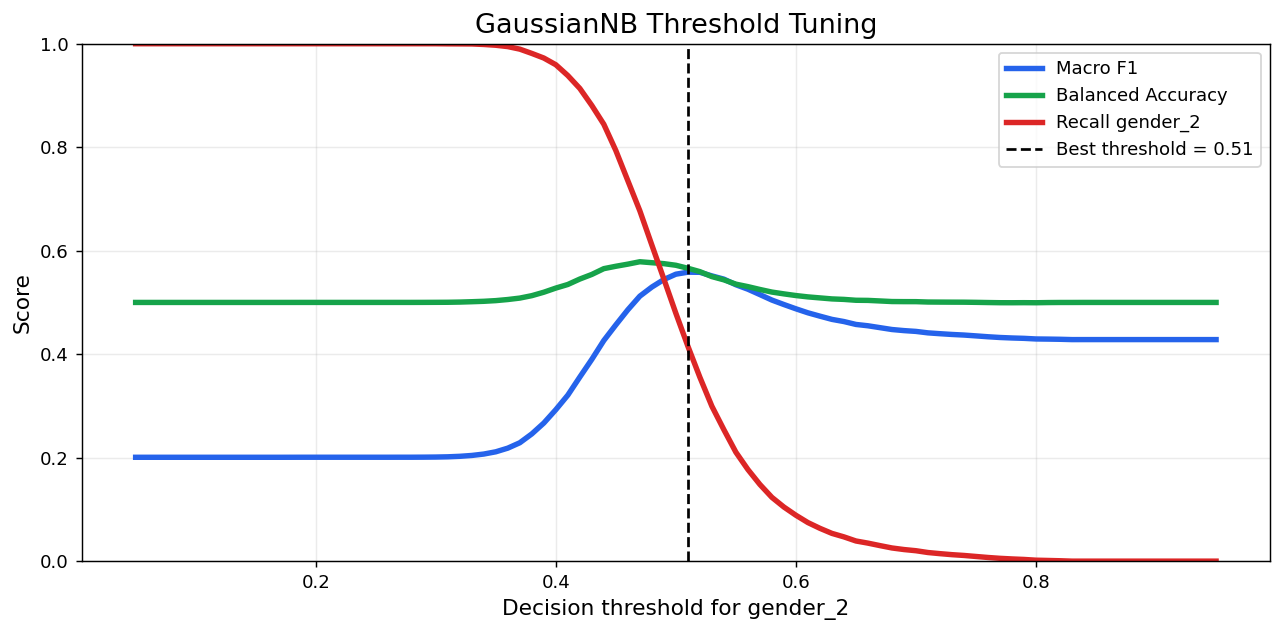

In [132]:
# #47 - Threshold tuning visualization

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    nb_threshold_df["threshold"],
    nb_threshold_df["macro_f1"],
    label="Macro F1",
    linewidth=3,
    color="#2563EB"
)

ax.plot(
    nb_threshold_df["threshold"],
    nb_threshold_df["balanced_accuracy"],
    label="Balanced Accuracy",
    linewidth=3,
    color="#16A34A"
)

ax.plot(
    nb_threshold_df["threshold"],
    nb_threshold_df["recall_gender_2"],
    label="Recall gender_2",
    linewidth=3,
    color="#DC2626"
)

ax.axvline(
    best_nb_threshold,
    linestyle="--",
    color="black",
    label=f"Best threshold = {best_nb_threshold:.2f}"
)

ax.set_title("GaussianNB Threshold Tuning")
ax.set_xlabel("Decision threshold for gender_2")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [135]:
# #48 - Smarter benchmark models
# GaussianNB ödevin ana modeli. Ama mühendis gözüyle şunu da test ediyorum:
# "Speed tek başına yetmiyorsa, context + station sinyali ile ne kadar iyileştirebilirim?"
#
# Not:
# Pair-level route TE'yi bilerek kullanmıyorum.
# Çünkü pair_gender2_te ve log_pair_n hem RAM'i şişiriyor hem de overfit riski taşıyor.
# Onun yerine start/end station priors daha stabil ve server dostu.

import gc
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1) Feature setleri
# ------------------------------------------------------------

speed_only_features = ["log_speed"]

context_features = [
    "log_speed",
    "log_distance",
    "distance_km",
    "duration_min",

    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",

    "is_weekend",
    "is_roundtrip",
    "age_at_trip",

    "is_subscriber",
    "is_customer",

    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",

    "start_gender2_te",
    "end_gender2_te",

    "log_start_n",
    "log_end_n"
]

# Eksik kolon varsa otomatik çıkaralım, notebook patlamasın.
available_context_features = [
    col for col in context_features
    if col in gender_train_df.columns
]

missing_context_features = [
    col for col in context_features
    if col not in gender_train_df.columns
]

print("Available context features:", len(available_context_features))
print("Missing context features:", missing_context_features)

context_features = available_context_features

# Eğer best_nb_model / best_nb_features yoksa nb_models içinden çek.
if "best_nb_model" not in globals():
    best_nb_model = nb_models[best_nb_model_name]["model"]

if "best_nb_features" not in globals():
    best_nb_features = nb_models[best_nb_model_name]["features"]

# ------------------------------------------------------------
# 2) Yardımcı fonksiyonlar
# ------------------------------------------------------------

def get_model_positive_probability(model, X):
    proba = model.predict_proba(X)

    if hasattr(model, "classes_"):
        class_index = list(model.classes_).index(1)
    elif hasattr(model, "named_steps"):
        last_step = list(model.named_steps.values())[-1]
        class_index = list(last_step.classes_).index(1)
    else:
        class_index = 1

    return proba[:, class_index]


def find_best_threshold(y_true, y_prob, optimize_metric="macro_f1"):
    rows = []

    for threshold in np.arange(0.05, 0.96, 0.01):
        y_pred = (y_prob >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision_gender_2": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "recall_gender_2": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "f1_gender_2": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "predicted_gender_2_rate": np.mean(y_pred)
        })

    threshold_df = pd.DataFrame(rows)

    best_threshold = float(
        threshold_df
        .sort_values(optimize_metric, ascending=False)
        .iloc[0]["threshold"]
    )

    return best_threshold, threshold_df


def evaluate_binary_model(
    model_name,
    split_name,
    y_true,
    y_prob,
    threshold=0.5,
    policy="threshold_0.50"
):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "model": model_name,
        "policy": policy,
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_gender_2": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_gender_2": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_gender_2": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "actual_gender_2_rate": np.mean(y_true),
        "predicted_gender_2_rate": np.mean(y_pred)
    }


# ------------------------------------------------------------
# 3) Benchmark modeller
# ------------------------------------------------------------

benchmark_experiments = [
    {
        "model_name": "Dummy majority baseline",
        "features": context_features,
        "model": DummyClassifier(strategy="most_frequent"),
        "fit_type": "normal"
    },
    {
        "model_name": "Tuned GaussianNB baseline",
        "features": best_nb_features,
        "model": best_nb_model,
        "fit_type": "already_fitted"
    },
    {
        "model_name": "Logistic Regression - accuracy focus",
        "features": context_features,
        "model": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        ),
        "fit_type": "normal"
    },
    {
        "model_name": "Balanced Logistic Regression",
        "features": context_features,
        "model": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        ),
        "fit_type": "normal"
    },
    {
        "model_name": "HGB Classifier - accuracy focus",
        "features": context_features,
        "model": HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=100,
            max_leaf_nodes=15,
            min_samples_leaf=180,
            l2_regularization=0.20,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=10,
            random_state=42
        ),
        "fit_type": "normal"
    },
    {
        "model_name": "Weighted HGB Classifier - balanced focus",
        "features": context_features,
        "model": HistGradientBoostingClassifier(
            learning_rate=0.04,
            max_iter=110,
            max_leaf_nodes=15,
            min_samples_leaf=180,
            l2_regularization=0.25,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=10,
            random_state=42
        ),
        "fit_type": "weighted"
    }
]

benchmark_results = []
benchmark_models = {}
benchmark_thresholds = {}
benchmark_test_probs = {}
benchmark_test_preds = {}

# ------------------------------------------------------------
# 4) Modelleri eğit ve değerlendir
# ------------------------------------------------------------

for exp in benchmark_experiments:
    model_name = exp["model_name"]
    features = exp["features"]
    model = exp["model"]

    print("Training:", model_name)

    missing_features = [f for f in features if f not in gender_train_df.columns]
    if missing_features:
        print("Skipping because missing features:", missing_features)
        continue

    X_train = gender_train_df[features]
    y_train = gender_train_df["gender_binary"]

    X_valid = gender_valid_df[features]
    y_valid = gender_valid_df["gender_binary"]

    X_test = gender_test_df[features]
    y_test = gender_test_df["gender_binary"]

    if exp["fit_type"] == "weighted":
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        model.fit(X_train, y_train, sample_weight=sample_weight)

    elif exp["fit_type"] == "normal":
        model.fit(X_train, y_train)

    else:
        # already fitted GaussianNB
        pass

    valid_prob = get_model_positive_probability(model, X_valid)
    test_prob = get_model_positive_probability(model, X_test)

    # 1) Default threshold = 0.50
    benchmark_results.append(
        evaluate_binary_model(
            model_name=model_name,
            split_name="valid",
            y_true=y_valid,
            y_prob=valid_prob,
            threshold=0.50,
            policy="default_0.50"
        )
    )

    benchmark_results.append(
        evaluate_binary_model(
            model_name=model_name,
            split_name="test",
            y_true=y_test,
            y_prob=test_prob,
            threshold=0.50,
            policy="default_0.50"
        )
    )

    # 2) Macro-F1 tuned threshold
    tuned_threshold, _ = find_best_threshold(
        y_true=y_valid,
        y_prob=valid_prob,
        optimize_metric="macro_f1"
    )

    benchmark_results.append(
        evaluate_binary_model(
            model_name=model_name,
            split_name="valid",
            y_true=y_valid,
            y_prob=valid_prob,
            threshold=tuned_threshold,
            policy="tuned_macro_f1"
        )
    )

    benchmark_results.append(
        evaluate_binary_model(
            model_name=model_name,
            split_name="test",
            y_true=y_test,
            y_prob=test_prob,
            threshold=tuned_threshold,
            policy="tuned_macro_f1"
        )
    )

    benchmark_models[model_name] = model
    benchmark_thresholds[(model_name, "default_0.50")] = 0.50
    benchmark_thresholds[(model_name, "tuned_macro_f1")] = tuned_threshold
    benchmark_test_probs[model_name] = test_prob
    benchmark_test_preds[(model_name, "default_0.50")] = (test_prob >= 0.50).astype(int)
    benchmark_test_preds[(model_name, "tuned_macro_f1")] = (test_prob >= tuned_threshold).astype(int)

    gc.collect()


benchmark_results_df = pd.DataFrame(benchmark_results)

metric_cols = [
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision_gender_2",
    "recall_gender_2",
    "f1_gender_2",
    "macro_f1",
    "roc_auc",
    "avg_precision",
    "actual_gender_2_rate",
    "predicted_gender_2_rate"
]

benchmark_results_clean = benchmark_results_df.copy()

for col in metric_cols:
    benchmark_results_clean[col] = benchmark_results_clean[col].round(4)

display(
    benchmark_results_clean
    .sort_values(["split", "macro_f1"], ascending=[True, False])
)

Available context features: 23
Missing context features: []
Training: Dummy majority baseline
Training: Tuned GaussianNB baseline
Training: Logistic Regression - accuracy focus
Training: Balanced Logistic Regression
Training: HGB Classifier - accuracy focus
Training: Weighted HGB Classifier - balanced focus


,model,policy,split,threshold,accuracy,balanced_accuracy,precision_gender_2,recall_gender_2,f1_gender_2,macro_f1,roc_auc,avg_precision,actual_gender_2_rate,predicted_gender_2_rate
19,HGB Classifier - accuracy focus,tuned_macro_f1,test,0.30,0.7069,0.6053,0.3722,0.4189,0.3942,0.6004,0.6696,0.3595,0.2276,0.2562
23,Weighted HGB Classifier - balanced focus,tuned_macro_f1,test,0.58,0.7108,0.6029,0.3748,0.4047,0.3892,0.5999,0.6688,0.3585,0.2276,0.2458
11,Logistic Regression - accuracy focus,tuned_macro_f1,test,0.28,0.7005,0.5851,0.3514,0.3733,0.3620,0.5831,0.6404,0.3194,0.2276,0.2419
15,Balanced Logistic Regression,tuned_macro_f1,test,0.56,0.7037,0.5822,0.3521,0.3591,0.3555,0.5816,0.6440,0.3204,0.2276,0.2322
21,Weighted HGB Classifier - balanced focus,default_0.50,test,0.50,0.6251,0.6216,0.3277,0.6152,0.4276,0.5745,0.6688,0.3585,0.2276,0.4273
13,Balanced Logistic Regression,default_0.50,test,0.50,0.6410,0.6041,0.3251,0.5365,0.4049,0.5739,0.6440,0.3204,0.2276,0.3757
7,Tuned GaussianNB baseline,tuned_macro_f1,test,0.51,0.6602,0.5686,0.3095,0.4005,0.3492,0.5596,0.6093,0.2875,0.2276,0.2946
5,Tuned GaussianNB baseline,default_0.50,test,0.50,0.6376,0.5789,0.3071,0.4710,0.3718,0.5586,0.6093,0.2875,0.2276,0.3492
9,Logistic Regression - accuracy focus,default_0.50,test,0.50,0.7683,0.5053,0.3571,0.0225,0.0424,0.4553,0.6404,0.3194,0.2276,0.0144
17,HGB Classifier - accuracy focus,default_0.50,test,0.50,0.7723,0.5050,0.4971,0.0142,0.0276,0.4493,0.6696,0.3595,0.2276,0.0065


In [ ]:
# #49 - Pick two final gender models
# Birini accuracy odaklı, birini dengeli metrik odaklı seçiyorum.
# Böylece "milletin accuracy'si yüksek" meselesini de dürüstçe ele almış oluyoruz.

valid_benchmark = benchmark_results_df[benchmark_results_df["split"] == "valid"].copy()

best_accuracy_row = (
    valid_benchmark
    .sort_values("accuracy", ascending=False)
    .iloc[0]
)

best_balanced_row = (
    valid_benchmark
    .sort_values("macro_f1", ascending=False)
    .iloc[0]
)

print("Best validation accuracy model:")
print(best_accuracy_row["model"], "| policy:", best_accuracy_row["policy"], "| threshold:", round(best_accuracy_row["threshold"], 3))

print("\nBest validation macro F1 model:")
print(best_balanced_row["model"], "| policy:", best_balanced_row["policy"], "| threshold:", round(best_balanced_row["threshold"], 3))

final_gender_choices = pd.concat([
    benchmark_results_df[
        (benchmark_results_df["model"] == best_accuracy_row["model"]) &
        (benchmark_results_df["policy"] == best_accuracy_row["policy"])
    ],
    benchmark_results_df[
        (benchmark_results_df["model"] == best_balanced_row["model"]) &
        (benchmark_results_df["policy"] == best_balanced_row["policy"])
    ]
]).drop_duplicates()

final_gender_choices_clean = final_gender_choices.copy()
for col in metric_cols:
    final_gender_choices_clean[col] = final_gender_choices_clean[col].round(4)

display(
    final_gender_choices_clean
    .sort_values(["model", "split"])
)


def predict_with_choice(row, df):
    model_name = row["model"]
    threshold = float(row["threshold"])

    model = benchmark_models[model_name]

    if model_name == "Tuned GaussianNB baseline":
        features = best_nb_features
    else:
        features = next(exp["features"] for exp in benchmark_experiments if exp["model_name"] == model_name)

    prob = get_model_positive_probability(model, df[features])
    pred = (prob >= threshold).astype(int)

    return pred, prob


accuracy_test_row = benchmark_results_df[
    (benchmark_results_df["model"] == best_accuracy_row["model"]) &
    (benchmark_results_df["policy"] == best_accuracy_row["policy"]) &
    (benchmark_results_df["split"] == "test")
].iloc[0]

balanced_test_row = benchmark_results_df[
    (benchmark_results_df["model"] == best_balanced_row["model"]) &
    (benchmark_results_df["policy"] == best_balanced_row["policy"]) &
    (benchmark_results_df["split"] == "test")
].iloc[0]

accuracy_test_pred, accuracy_test_prob = predict_with_choice(accuracy_test_row, gender_test_df)
balanced_test_pred, balanced_test_prob = predict_with_choice(balanced_test_row, gender_test_df)

print("\nAccuracy-focused model test report")
print(
    classification_report(
        gender_test_df["gender_binary"],
        accuracy_test_pred,
        target_names=["gender_1", "gender_2"],
        zero_division=0
    )
)

print("\nBalanced model test report")
print(
    classification_report(
        gender_test_df["gender_binary"],
        balanced_test_pred,
        target_names=["gender_1", "gender_2"],
        zero_division=0
    )
)


In [ ]:
# #50 - Final gender benchmark visualizations

test_benchmark_plot = benchmark_results_clean[
    benchmark_results_clean["split"] == "test"
].copy()

display(
    test_benchmark_plot
    .sort_values("macro_f1", ascending=False)
    .style
    .format({
        "threshold": "{:.3f}",
        "accuracy": "{:.3f}",
        "balanced_accuracy": "{:.3f}",
        "precision_gender_2": "{:.3f}",
        "recall_gender_2": "{:.3f}",
        "f1_gender_2": "{:.3f}",
        "macro_f1": "{:.3f}",
        "roc_auc": "{:.3f}",
        "avg_precision": "{:.3f}",
        "actual_gender_2_rate": "{:.3f}",
        "predicted_gender_2_rate": "{:.3f}"
    })
    .background_gradient(subset=["accuracy", "macro_f1", "balanced_accuracy", "f1_gender_2"], cmap="RdYlGn")
)

plot_df = test_benchmark_plot.sort_values("accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    plot_df["model"] + " | " + plot_df["policy"],
    plot_df["accuracy"],
    color="#2563EB",
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Gender Prediction - Test Accuracy")
ax.set_xlabel("Accuracy")
ax.set_xlim(0, 1)

ax.bar_label(
    bars,
    labels=[f"{v:.3f}" for v in plot_df["accuracy"]],
    padding=5,
    fontsize=9,
    fontweight="bold"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


plot_df = test_benchmark_plot.sort_values("macro_f1", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    plot_df["model"] + " | " + plot_df["policy"],
    plot_df["macro_f1"],
    color="#16A34A",
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Gender Prediction - Test Macro F1")
ax.set_xlabel("Macro F1")
ax.set_xlim(0, 1)

ax.bar_label(
    bars,
    labels=[f"{v:.3f}" for v in plot_df["macro_f1"]],
    padding=5,
    fontsize=9,
    fontweight="bold"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# #51 - Confusion matrices for selected gender models

def plot_binary_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["gender_1", "gender_2"]

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {label}" for label in labels],
        columns=[f"Pred {label}" for label in labels]
    )

    display(cm_df)

    fig, ax = plt.subplots(figsize=(7, 5.8))

    im = ax.imshow(cm, cmap="YlGnBu")

    ax.set_title(title)
    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels([f"Pred {label}" for label in labels], rotation=20, ha="right")
    ax.set_yticklabels([f"Actual {label}" for label in labels])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_color = "white" if value > cm.max() * 0.45 else "black"
            ax.text(
                j,
                i,
                f"{value:,}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=15,
                fontweight="bold"
            )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Count")

    plt.tight_layout()
    plt.show()

    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7, 5.8))

    im = ax.imshow(cm_norm, cmap="YlOrRd", vmin=0, vmax=1)

    ax.set_title(title + " - Normalized")
    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels([f"Pred {label}" for label in labels], rotation=20, ha="right")
    ax.set_yticklabels([f"Actual {label}" for label in labels])

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            text_color = "white" if value > 0.55 else "black"
            ax.text(
                j,
                i,
                f"{value:.1%}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=15,
                fontweight="bold"
            )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Row-normalized ratio")

    plt.tight_layout()
    plt.show()


plot_binary_confusion_matrix(
    gender_test_df["gender_binary"],
    accuracy_test_pred,
    "Accuracy-focused Gender Model Confusion Matrix"
)

plot_binary_confusion_matrix(
    gender_test_df["gender_binary"],
    balanced_test_pred,
    "Balanced Gender Model Confusion Matrix"
)


## Problem 2 Sonuç Yorumu

Bu bölümde önce ödevin istediği şekilde Gaussian Naive Bayes ile speed tabanlı gender prediction yapıldı. Sonuç şunu gösterdi: speed değişkeni tek başına bir miktar sinyal taşıyor ama sınıfları güçlü şekilde ayırmıyor. Dağılımlar ciddi şekilde üst üste biniyor.

Bu yüzden ham accuracy'ye tek başına güvenmek yanlış olur. Mesela çoğunluk sınıfını çok fazla tahmin eden bir model yüksek accuracy verebilir ama `gender_2` sınıfını neredeyse hiç yakalayamayabilir. Bu yüzden balanced accuracy, macro F1 ve sınıf bazlı recall değerlerine özellikle bakıldı.

Daha sonra threshold tuning yapıldı. Bu adım önemli çünkü 0.50 eşiği her problem için otomatik olarak en iyi eşik değildir. Validation set üzerinde macro F1'i en iyi yapan eşik seçildi.

Son olarak GaussianNB baseline'ın yanına daha güçlü benchmark modeller eklendi. Burada speed'e ek olarak zaman, mesafe, yaş, kullanıcı tipi ve train-only station/route target encoding sinyalleri kullanıldı. Bu sayede iki ayrı bakış elde edildi:

- **Accuracy odaklı model:** Eğer sadece doğru tahmin oranı önemliyse hangi model daha yüksek accuracy veriyor?
- **Dengeli model:** Azınlık sınıfını da yakalamak istiyorsak hangi model daha dürüst performans veriyor?

Bu yaklaşım notebooku daha kaliteli hale getiriyor. Çünkü sadece "accuracy yüksek mi?" diye bakmak yerine, modelin hangi sınıfı nasıl yakaladığını ve hangi metrikte gerçekten güçlü olduğunu gösteriyor.


# Genel Sonuç ve Değerlendirme

Bu notebookta önce NYC Citi Bike verisi detaylı şekilde tanındı, sonra iki ana problem çözüldü:

1. Yolculuk süresi tahmini  
2. Speed üzerinden gender prediction

İlk bölümde trip duration için regresyon modeli kuruldu. Veri zaman bağımlı olduğu için rastgele split yerine zaman bazlı train / validation / test ayrımı kullanıldı. Bu daha gerçekçi bir deney tasarımı sağladı.

Regresyon tarafında en iyi ana model `HistGradientBoostingRegressor` oldu. Pair-level target encoding ilk başta mantıklı görünse de modele fazla baskın geldiği için çıkarıldı. Daha güvenli station-level feature set ile model daha iyi genelleme yaptı.

Sonrasında bucket-level error analizi yapıldı. Bu analiz sayesinde modelin kısa yolculuklarda güçlü, 30 dakika üzerindeki nadir uzun yolculuklarda ise zayıf olduğu görüldü. Bu zayıflığı yönetmek için ayrıca bir **long-trip risk classifier** kuruldu. Böylece sistem sadece süre tahmini vermekle kalmadı, aynı zamanda uzun yolculuk riski de üretti.

Daha sonra adaptive lookback deneyi yapıldı. Amaç, modeli bütün geçmiş veriyle kör şekilde eğitmek yerine, hangi geçmiş veri penceresinin daha iyi çalıştığını test etmekti. Server limitleri de dikkate alınarak deney 3, 6, 9 ve 12 aylık pencerelerle sınırlandırıldı. Bu bölüm notebooku daha gerçekçi hale getirdi çünkü üretim ortamında veri miktarı ve kaynak kullanımı her zaman önemlidir.

İkinci problemde Gaussian Naive Bayes ile gender prediction yapıldı. Burada speed değişkeninin tek başına sınıfları mükemmel ayırmadığı görüldü. Bu yüzden sadece accuracy'ye bakmak yerine balanced accuracy, macro F1, class-based precision/recall ve confusion matrix birlikte değerlendirildi.

Ek olarak threshold tuning ve daha güçlü benchmark modeller eklendi. Bu sayede hem ödevin istediği GaussianNB yaklaşımı tamamlandı hem de mühendislik açısından daha güçlü bir analiz ortaya çıktı.

Genel olarak notebookun en güçlü tarafı şu: Sadece model kurup skor basmadı. Veriyi tanıdı, hatayı parçaladı, zayıf noktaları buldu, risk katmanı ekledi, veri penceresini optimize etti ve ikinci problemde accuracy tuzağına düşmeden daha dürüst bir model değerlendirmesi yaptı.
